- **Name:**  imed-eddine benmadi
- **Neptun ID:** DXU35B
- **github link:** https://github.com/imadbenmadi/Image_Caption
- **kaggle link:** https://www.kaggle.com/code/imedbenmadi/asseignment-dnd
- **collab link:** https://colab.research.google.com/drive/1NbG4yWXkFzBb9oWqU0J-FjlfvKNgfwtt?usp=sharing

# **Assignment 1 - Image Captioning**

<div style="border: 3px solid #222; padding: 16px; border-radius: 10px; background-color: #1c1f26; font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif; color: #e0e0e0;">
  <div style="display: flex; align-items: center; gap: 8px; margin-top: 12px;">
    <span style="font-size: 24px; color: #ff5555;">&#128274;</span>
    <span style="font-size: 16px;"><strong>Project:</strong> Assignments</span>
  </div>
  <div style="display: flex; align-items: center; gap: 8px; margin-top: 8px;">
    <span style="font-size: 20px; color: #ff5555;">&#128218;</span>
    <span style="font-size: 16px;"><strong>Course:</strong> Deep Network Development</span>
  </div>
  <div style="margin-top: 12px; font-size: 14px;">
    <span style="font-size: 18px; color: #6e8192;">&#128100;</span>
    <span style="font-weight: bold;"><strong>Authors:</strong></span> Tamás Takács, Imre Molnár (PhD students, Department of Artificial Intelligence, Eötvös Loránd University)
  </div>
</div>
<hr style="border: none; border-top: 2px solid #444;">
<br>

<img src="https://repository-images.githubusercontent.com/83958320/8f162500-8ace-11e9-94ee-0b86d27bbc5e" alt="1" border="0">


# Image Captioning with Encoder-Attention-Decoder Architecture

This notebook implements an image captioning model using an encoder-attention-decoder architecture on the Flickr8k dataset. I'll build a custom model with attention mechanism and compare its performance with a pre-trained model.

## Overview

Image captioning combines computer vision and natural language processing to generate textual descriptions of images. Our approach uses:

1. **Encoder**: A CNN (typically ResNet) to extract image features
2. **Attention**: A mechanism that helps the model focus on relevant parts of the image
3. **Decoder**: An LSTM that generates captions word by word

and the evaluation of the model we be done using BLEU scores and compare it with a pre-trained model.

## 1. Import Required Libraries

In [1]:
import os
import zipfile
import torch
import nltk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torchvision
from torch import nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from collections import Counter
import random
from tqdm.notebook import tqdm
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu
from transformers import VisionEncoderDecoderModel, ViTImageProcessor, AutoTokenizer
import urllib.request
import warnings
import transformers
from nltk.translate.bleu_score import SmoothingFunction


2025-04-28 16:21:08.505207: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745857268.697631      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745857268.750114      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered



### Optimized GPU Setup for Training

**sets up the environment for optimized training using a GPU (if available).** 

1. **Device Selection**:
   - The code checks if a CUDA-compatible GPU is available.
   - If a GPU is available, it sets the device to `cuda:0`. Otherwise, it defaults to the CPU.

2. **CUDA Optimizations**:
   - Enables **cuDNN benchmarking** (`cudnn.benchmark = True`) for better performance with convolutional neural networks (CNNs).
   - Prints GPU information, including:
     - GPU name.
     - Memory allocated and reserved on the GPU.

3. **Mixed Precision Training**:
   - If a GPU is available, it initializes a **gradient scaler** (`torch.amp.GradScaler`) for mixed precision training, which can improve training speed and reduce memory usage.
   - Mixed precision training is enabled by setting `use_amp = True`.

4. **Fallback to CPU**:
   - If no GPU is available, it sets the device to CPU and disables mixed precision training (`use_amp = False`).



In [2]:
# Optimized GPU setup for Kaggle
import torch.backends.cudnn as cudnn
import torch.amp

# Set device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Enable CUDA optimizations
if torch.cuda.is_available():
    # Enable cuDNN benchmarking for better performance with CNNs
    cudnn.benchmark = True
    
    # Print GPU information
    print(f"Using device: {device}")
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory allocated: {torch.cuda.memory_allocated(0) / 1e9:.2f} GB")
    print(f"Memory reserved: {torch.cuda.memory_reserved(0) / 1e9:.2f} GB")  # Updated from memory_cached
    
    # Updated GradScaler initialization
    scaler = torch.amp.GradScaler('cuda')  # Updated from torch.cuda.amp.GradScaler()
    use_amp = True
    print("Mixed precision training enabled")
else:
    use_amp = False
    print("Using CPU - no CUDA available")

Using device: cuda:0
GPU: Tesla P100-PCIE-16GB
Memory allocated: 0.00 GB
Memory reserved: 0.00 GB
Mixed precision training enabled


## 2. Data Loading and Exploration

use the Flickr8k dataset, which contains 8,000 images, each with 5 different captions. First, we need to download and extract the dataset.

In [4]:
# # Install Kaggle package
!pip install -q kaggle

# Create directory for Kaggle credentials
os.makedirs('/root/.kaggle', exist_ok=True)

with open('/root/.kaggle/kaggle.json', 'w') as f:
    f.write('{"username":"imedbenmadi","key":"7c4259cfcfc4f0c8d55c68269d618f8d"}')
os.chmod('/root/.kaggle/kaggle.json', 600)

# Download the dataset (uncomment the lines below when ready to download)
!kaggle datasets download -d adityajn105/flickr8k

with zipfile.ZipFile('flickr8k.zip', 'r') as zip_ref:
    zip_ref.extractall('flickr8k_data')

Dataset URL: https://www.kaggle.com/datasets/adityajn105/flickr8k
License(s): CC0-1.0


In [5]:
with zipfile.ZipFile('flickr8k.zip', 'r') as zip_ref:
    zip_ref.extractall('flickr8k_data')

**exploring the dataset structure.**

In [6]:
# Define paths to images and captions
BASE_DIR = 'flickr8k_data'
IMAGES_DIR = os.path.join(BASE_DIR, 'Images')
CAPTIONS_FILE = os.path.join(BASE_DIR, 'captions.txt')

# Check if dataset is properly extracted
if os.path.exists(BASE_DIR) and os.path.exists(IMAGES_DIR) and os.path.exists(CAPTIONS_FILE):
    print(f"Dataset is properly set up.")
    print(f"Images directory: {IMAGES_DIR}")
    print(f"Captions file: {CAPTIONS_FILE}")
    print(f"Number of images: {len(os.listdir(IMAGES_DIR))}")
else:
    print("Dataset not found. Please download and extract the Flickr8k dataset.")

Dataset is properly set up.
Images directory: flickr8k_data/Images
Captions file: flickr8k_data/captions.txt
Number of images: 8091


**Load captions from file**

In [7]:
def load_captions(captions_file):
    all_captions = {}
    with open(captions_file, 'r') as f:
        next(f)  # Skip header line
        for line in f:
            line = line.strip().split(',')
            image_name = line[0].split('#')[0].strip()
            caption = line[1].strip()
            
            if image_name not in all_captions:
                all_captions[image_name] = []
            all_captions[image_name].append(caption)
    
    return all_captions

# Load all captions
all_captions = load_captions(CAPTIONS_FILE)
print(f"Total number of images with captions: {len(all_captions)}")
print(f"Sample of captions for one image:")
sample_image = list(all_captions.keys())[0]
print(f"Image: {sample_image}")
for i, caption in enumerate(all_captions[sample_image]):
    print(f"Caption {i+1}: {caption}")

Total number of images with captions: 8091
Sample of captions for one image:
Image: 1000268201_693b08cb0e.jpg
Caption 1: A child in a pink dress is climbing up a set of stairs in an entry way .
Caption 2: A girl going into a wooden building .
Caption 3: A little girl climbing into a wooden playhouse .
Caption 4: A little girl climbing the stairs to her playhouse .
Caption 5: A little girl in a pink dress going into a wooden cabin .


**visualize a few images along with their captions to better understand the dataset.**

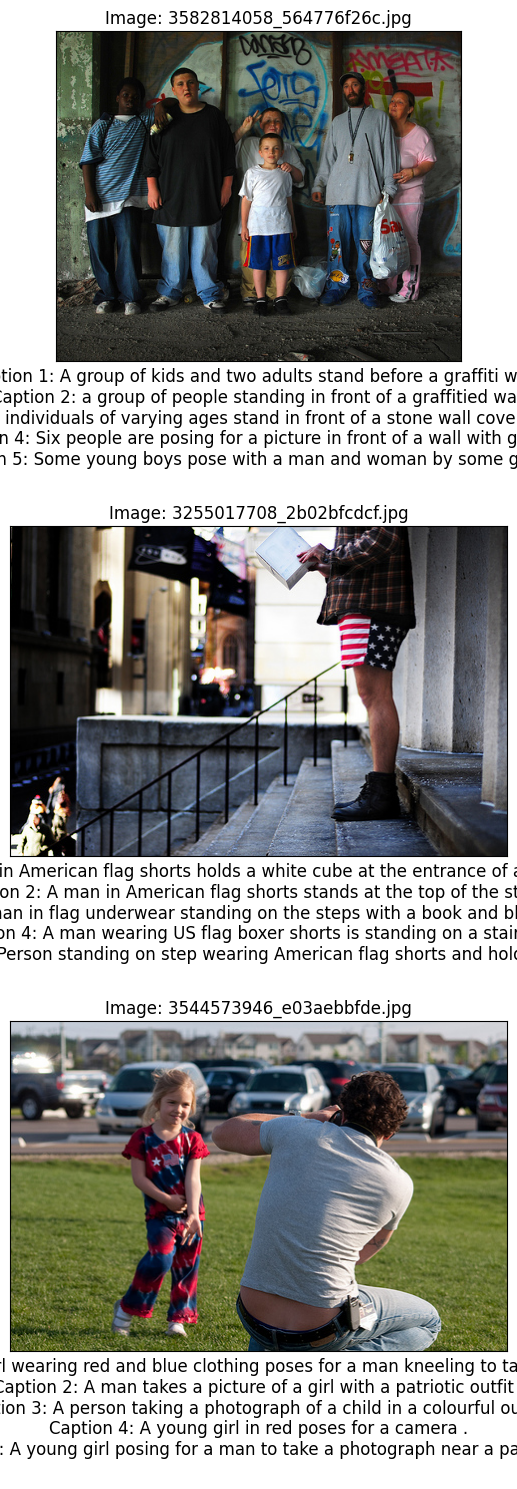

In [ ]:
# Visualize sample images with captions
def show_images_with_captions(all_captions, images_dir, num_samples=3):
    plt.figure(figsize=(15, 5*num_samples))
    image_names = list(all_captions.keys())
    samples = random.sample(image_names, num_samples)
    
    for i, image_name in enumerate(samples):
        # Load and display the image
        image_path = os.path.join(images_dir, image_name)
        image = Image.open(image_path)
        
        plt.subplot(num_samples, 1, i+1)
        plt.imshow(image)
        plt.title(f"Image: {image_name}", fontsize=12)
        
        # Display captions
        caption_text = ""
        for j, caption in enumerate(all_captions[image_name]):
            caption_text += f"Caption {j+1}: {caption}\n"
        
        plt.xlabel(caption_text, fontsize=12)
        plt.xticks([])
        plt.yticks([])
    
    plt.tight_layout()
    plt.show()

# Show sample images with captions
show_images_with_captions(all_captions, IMAGES_DIR, num_samples=3)

## 3. Data Preprocessing 

prepare our data for the model by:
1. **Defining image transformations for training and testing**
2. **Creating a dataset class to load images and captions**
3. **Setting up dataloaders with appropriate batch sizes and padding**



> `transforms.Compose([...])` is a PyTorch utility that **sequentially applies a list of transformations** to an input image.  
> It allows for building a **preprocessing pipeline** where each transformation is executed in the defined order.


###  `train_transforms` (for training data)


| Transform | Purpose |
|:---|:---|
| `RandomHorizontalFlip(p=0.5)` | 50% chance to flip the image horizontally (simulate different views) |
| `RandomRotation(10)` | Randomly rotate image by ±10 degrees (add rotation variation) |
| `ColorJitter` | Randomly change brightness, contrast, and saturation (simulate lighting changes) |
| `Resize((224, 224))` | Resize all images to 224×224 pixels (standard size for CNNs) |
| `ToTensor()` | Convert image from PIL/numpy to a PyTorch tensor |
| `Normalize(mean, std)` | Normalize pixel values using ImageNet statistics (center the data) |

 **Goal:**  
**Make training images more random and diverse**,  
so the model becomes more **robust** and **generalizes better** to new data.

---

###  `test_transforms` (for testing/validation data)


| Transform | Purpose |
|:---|:---|
| `Resize((224, 224))` | Ensure consistent input size |
| `ToTensor()` | Convert image to tensor |
| `Normalize(mean, std)` | Standardize pixel values |

 **Goal:**  
**Keep test images clean and consistent**,  
**no randomness**

---


- **Training transforms** = *add randomness* ✅
- **Testing transforms** = *keep it clean and fair* ✅


In [9]:
# Define image transformations
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

## 4. Build Vocabulary

#### **Before creating our dataset class, we need to build a vocabulary to convert words to indices and vice versa. only include words that appear at least 5 times to reduce the vocabulary size.**


**tokenizing text** — meaning **breaking text into words or sentences**.

🔵 **`punkt`** is a pretrained model inside NLTK that knows *where to split sentences or words* based on English grammar.

```python
from nltk.tokenize import word_tokenize

sentence = "Hello bro, how are the?"
tokens = word_tokenize(sentence)
print(tokens)
```
Output:
```
['Hello', 'bro', ',', 'how', 'are', 'the', '?']
```


In [ ]:

# Try more specific download commands
nltk.download('punkt')  # This downloads the punkt tokenizer data

# Force download with verbose output 
print("Downloading NLTK punkt package...")
try:
    nltk.download('punkt', quiet=False)
    nltk.download('punkt_tab', quiet=False)
    print("Download successful!")
except Exception as e:
    print(f"Error during download: {e}")
from nltk.tokenize import word_tokenize


Download successful!


[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [2]:
# Simple custom tokenizer function that doesn't rely on NLTK
def custom_tokenizer(text):
    """
    A simple tokenization function that doesn't rely on NLTK restheces.
    This handles basic punctuation and splits text into words.
    
    Args:
        text (str): Text to tokenize
        
    Returns:
        list: List of tokens
    """
    # Convert to lowercase
    text = text.lower()
    
    # Replace punctuation with spaces before/after
    for punct in '.,;:!?"\'()[]{}':
        text = text.replace(punct, f' {punct} ')
    
    # Split by whitespace and filter out empty strings
    tokens = [token for token in text.split() if token]
    
    return tokens


# Test the tokenizer on a sample caption
print("_____________________________________________")
sample_caption = all_captions[sample_image][0]
print(f"Sample caption: {sample_caption}")
print(f"Tokenized caption with custom_tokenizer : {custom_tokenizer(sample_caption)}")
print("_____________________________________________")
# trying the nltk tokenizer 
sample_caption = all_captions[sample_image][0]
print(f"Sample caption: {sample_caption}")
print(f"Tokenized caption with nltk: {word_tokenize(sample_caption)}")




_____________________________________________


NameError: name 'all_captions' is not defined

### Vocabulary Class

The `Vocabulary` class is a custom implementation for building and managing a vocabulary for text data. It does not rely on external libraries like NLTK for tokenization or vocabulary management. 
**This class is essential for converting textual data into numerical format, which is required for training machine learning models.**
1. **Initialization**:
    - Defines special tokens:
      - `<pad>`: Padding token.
      - `<sos>`: Start-of-sequence token.
      - `<eos>`: End-of-sequence token.
      - `<unk>`: Unknown token for out-of-vocabulary words.
    - Initializes two dictionaries:
      - `itos` (index-to-string): Maps indices to words.
      - `stoi` (string-to-index): Maps words to indices.
    - Sets a frequency threshold (`freq_threshold`) to filter out infrequent words.
    - Starts indexing from 4 (after the special tokens).

2. **Building the Vocabulary**:
    - The `build_vocabulary` method takes a dictionary of image captions (`captions_dict`) as input.
    - It counts the frequency of each word across all captions using the `Counter` class.
    - Words that appear at least `freq_threshold` times are added to the vocabulary with a unique index.

3. **Numericalizing Text**:
    - The `numericalize` method converts a given text into a list of indices based on the vocabulary.
    - If a word is not in the vocabulary, it is replaced with the `<unk>` token.

4. **Custom Tokenizer**:
    - The class uses a `custom_tokenizer` function (defined elsewhere) to tokenize text into words.



1- **During building,  scan all captions and create a dictionary of important words with their numbers.**

2- **During training,  convert captions into numbers before feeding them to the model.**

3- **During inference, after generating numbers,  convert numbers back into words to get a readable caption.**

### 1. `build_vocabulary(captions_dict)`
- For each caption in the dataset:
  - **Tokenize** it (split into words).
  - **Count** how many times each word appears.
- **After counting all words**:
  - Only add the words that appear **more than `freq_threshold` times**.
  - Assign them a unique index.

This step **builds the final vocabulary**.

---

### 2. `numericalize(text)`
- When we input a sentence (example: `"A cat on the mat"`):
  - Tokenize the sentence into words: `["a", "cat", "on", "the", "mat"]`
  - Convert each word to its index:
    - if the word exists in `stoi`, use its index.
    - else, use the `<unk>` index (unknown word).

This prepares sentences to be given to the model.


#### Example

Suppose we build the vocab and it becomes like:

| Word | Index |
|:---|:---|
| `<pad>` | 0 |
| `<sos>` | 1 |
| `<eos>` | 2 |
| `<unk>` | 3 |
| `dog` | 4 |
| `on` | 5 |
| `grass` | 6 |

Then if we call:

```python
vocab.numericalize("dog on grass")
```
we will get:
```python
[4, 5, 6]
```

And if the model outputs `[4, 5, 6, 2]`,  decode it using `itos` and get:
```text
dog on grass <eos>
```


we can then numericalize (convert a sentence to numbers):

```python
indices = vocab.numericalize("a cat sits on a mat")
# Output might be [1, 23, 47, 53, 23, 102]
```


## **build_vocabulary explanation**


**The function counts the frequency of each word in the captions and assigns an index to each word that meets the frequency threshold. The special tokens pad, sos, eos, and unk are also included in the vocabulary. The function uses a custom tokenizer (custom_tokenizer) to tokenize the captions instead of relying on NLTK.**

### **`captions_dict` should look like**

The parameter `captions_dict` is expected to be a dictionary like this:

```python
captions_dict = {
    "image1.jpg": ["A dog is running in the park", "A dog runs outdoors"],
    "image2.jpg": ["A cat is sleeping on the sofa"],
    "image3.jpg": ["A group of people are hiking in the mountains"]
}
```

- **Key**: image filename or ID (can be anything like `"img123"`).
- **Value**: a **list of captions** (strings) describing the image which is five for each image in our dataset.

---


#### Word Frequencies
```plaintext
'a': appears 5 times
'dog': 2
'is': 2
'running': 1
'in': 2
'the': 3
'park': 1
'runs': 1
'outdoors': 1
'cat': 1
'sleeping': 1
'on': 1
'sofa': 1
'group': 1
'of': 1
'people': 1
'are': 1
'hiking': 1
'mountains': 1
```

With `freq_threshold=2`, only the following words get added:
- `a`, `dog`, `is`, `in`, `the`

All others are **ignored** in the vocabulary.

---

###  **Output**

```python
vocab.itos = {
    0: "<pad>",
    1: "<sos>",
    2: "<eos>",
    3: "<unk>",
    4: "a",
    5: "dog",
    6: "is",
    7: "in",
    8: "the"
}
```

```python
vocab.stoi = {
    "<pad>": 0,
    "<sos>": 1,
    "<eos>": 2,
    "<unk>": 3,
    "a": 4,
    "dog": 5,
    "is": 6,
    "in": 7,
    "the": 8
}
```

---

### **Using `numericalize`**

```python
vocab.numericalize("A cat is in the house")
```

- Tokenized: `['a', 'cat', 'is', 'in', 'the', 'house']`
- Word-to-index:
  - `"a"` → 4 ✅
  - `"cat"` → `<unk>` → 3 ❌
  - `"is"` → 6 ✅
  - `"in"` → 7 ✅
  - `"the"` → 8 ✅
  - `"house"` → `<unk>` → 3 ❌

 Output:
```python
[4, 3, 6, 7, 8, 3]
```


In [ ]:
class Vocabulary:
    def __init__(self, freq_threshold=5, use_pretrained=False, embed_dim=300):
        # Special tokens
        self.itos = {0: "<pad>", 1: "<sos>", 2: "<eos>", 3: "<unk>"}
        self.stoi = {"<pad>": 0, "<sos>": 1, "<eos>": 2, "<unk>": 3}
        self.freq_threshold = freq_threshold
        self.index = 4  # Next index to assign
        self.use_pretrained = use_pretrained
        self.embed_dim = embed_dim
        self.embeddings = None
        
    def __len__(self):
        return len(self.itos)
    
    def build_vocabulary(self, captions_dict):
        # Count word frequencies across all captions
        word_counts = Counter()
        
        for img_id, captions in captions_dict.items():
            for caption in captions:
                # Use our custom tokenizer
                tokens = custom_tokenizer(caption)
                word_counts.update(tokens)
        '''
            example of the update method of the Counter class:
            word_counts = Counter()
            word_counts.update(['a', 'b', 'c'])
            word_counts.update(['a', 'b'])
            print(word_counts)  # Counter({'a': 3, 'b': 2, 'c': 1})    
        '''
        # Add words that meet the frequency threshold
        for word, count in word_counts.items():
            if count >= self.freq_threshold:
                self.stoi[word] = self.index
                self.itos[self.index] = word
                self.index += 1
        '''
            example of the vocabulary class:
            vocab = Vocabulary(freq_threshold=2)
            captions_dict = {
                'image1.jpg': ['a cat on a mat', 'a dog on a log'],
                'image2.jpg': ['a cat and a dog']
            }
            vocab.build_vocabulary(captions_dict)
            print(vocab.stoi)  # {'<pad>': 0, '<sos>': 1, '<eos>': 2, '<unk>': 3, 'a': 4, 'cat': 5, 'on': 6, 'mat': 7, 'dog': 8, 'log': 9, 'and': 10}
            print(vocab.itos)  # {0: '<pad>', 1: '<sos>', 2: '<eos>', 3: '<unk>', 4: 'a', 5: 'cat', 6: 'on', 7: 'mat', 8: 'dog', 9: 'log', 10: 'and'}

        '''
        print(f"Vocabulary built with {len(self.itos)} words")
        
        # Load pre-trained embeddings if requested
        if self.use_pretrained:
            try:
                self.load_glove_embeddings()
            except Exception as e:
                print(f"Could not load pretrained embeddings: {e}")
                print("Continuing with randomly initialized embeddings")
                self.use_pretrained = False
    
    def load_glove_embeddings(self):
        """Load GloVe embeddings for vocabulary words"""
        print("Loading GloVe embeddings...")
        
        # Download GloVe if not available
        if not os.path.exists('glove.6B'):
            print("Downloading GloVe embeddings...")
            
            # Create directory for GloVe
            os.makedirs('glove.6B', exist_ok=True)
            
            # Download GloVe embeddings
            urllib.request.urlretrieve(
                "https://nlp.stanford.edu/data/glove.6B.zip",
                "glove.6B/glove.6B.zip"
            )
            
            # Extract GloVe embeddings
            with zipfile.ZipFile("glove.6B.zip", "r") as zip_ref:
                zip_ref.extractall("glove.6B")
        
        # Initialize embeddings matrix
        embeddings = np.random.normal(scale=0.6, size=(len(self), self.embed_dim))
        
        # Load GloVe embeddings
        glove_path = f'glove.6B/glove.6B.{self.embed_dim}d.txt'
        found_words = 0
        
        with open(glove_path, 'rb') as f:
            for line in tqdm(f, desc='Loading GloVe'):
                parts = line.decode('utf-8').strip().split(' ')
                word = parts[0]
                
                if word in self.stoi:
                    vector = np.array([float(val) for val in parts[1:]])
                    embeddings[self.stoi[word]] = vector
                    found_words += 1
        
        # Set embeddings
        self.embeddings = torch.from_numpy(embeddings).float()
        print(f"Loaded {found_words} words from GloVe ({found_words/len(self):.1%} of vocabulary)")
    
    def get_embeddings(self):
        """Return embeddings matrix, or None if not using pretrained embeddings"""
        return self.embeddings
    
    def numericalize(self, text):
        # Convert a text to a list of indices
        tokenized_text = custom_tokenizer(text)
        '''
          When the `numericalize()` method encounters a word that
          isn't in the vocabulary (because it appeared fewer than 10 times),
          it replaces that word with the `<unk>` token (unknown word token).
        '''
        return [
            self.stoi[token] if token in self.stoi else self.stoi["<unk>"]
            for token in tokenized_text
        ]

In [ ]:
# Create and build vocabulary
# vocab = Vocabulary(freq_threshold=10 )
vocab = Vocabulary(freq_threshold=5 ) # for a better performance
vocab.build_vocabulary(all_captions)


Vocabulary built with 1918 words


**create our custom dataset class for the Flickr8k dataset.**

In [ ]:
class FlickrDataset(Dataset):
    def __init__(self, root_dir, captions_dict, vocab, transform=None, split='train'):
        self.root_dir = root_dir
        self.vocab = vocab
        self.transform = transform
        
        # Create training, validation, and test splits
        all_images = list(captions_dict.keys())
        random.seed(42)
        random.shuffle(all_images)
        
        # Split data: 70% train, 15% validation, 15% test
        train_size = int(0.7 * len(all_images))
        val_size = int(0.15 * len(all_images))
        
        if split == 'train':
            self.image_ids = all_images[:train_size]
        elif split == 'val':
            self.image_ids = all_images[train_size:train_size+val_size]
        elif split == 'test':
            self.image_ids = all_images[train_size+val_size:]
        
        # Flatten list of image-caption pairs
        self.image_captions = []
        for img_id in self.image_ids:
            for caption in captions_dict[img_id]:
                self.image_captions.append((img_id, caption))
        
        print(f"{split} dataset contains {len(self.image_captions)} image-caption pairs for {len(self.image_ids)} unique images")
    
    def __len__(self):
        return len(self.image_captions)
    
    def __getitem__(self, idx):
        # the method is used by PyTorch's DataLoader to get **one sample** (image + caption) from the dataset.
        img_id, caption = self.image_captions[idx]
        img_path = os.path.join(self.root_dir, img_id)
        
        # Read and transform image
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        
        # Prepare caption
        #  Example: "a cat sits" → [1, 12, 34, 56, 2] whith 1 = <sos>, 2 = <eos>
        numericalized_caption = [self.vocab.stoi["<sos>"]]
        numericalized_caption += self.vocab.numericalize(caption)
        numericalized_caption.append(self.vocab.stoi["<eos>"])
        
        caption_length = len(numericalized_caption)


        '''
            - image: the transformed image (as a tensor)
            - torch.tensor(numericalized_caption): the caption converted to a tensor of word indices
            - caption_length: the number of tokens (used later for padding or packing)
        '''
        return image, torch.tensor(numericalized_caption), caption_length

# Create datasets for train, val, and test
train_dataset = FlickrDataset(
    root_dir=IMAGES_DIR,
    captions_dict=all_captions,
    vocab=vocab,
    transform=train_transforms,
    split='train'
)

val_dataset = FlickrDataset(
    root_dir=IMAGES_DIR,
    captions_dict=all_captions,
    vocab=vocab,
    transform=test_transforms,
    split='val'
)

test_dataset = FlickrDataset(
    root_dir=IMAGES_DIR,
    captions_dict=all_captions,
    vocab=vocab,
    transform=test_transforms,
    split='test'
)


train dataset contains 28315 image-caption pairs for 5663 unique images
val dataset contains 6065 image-caption pairs for 1213 unique images
test dataset contains 6075 image-caption pairs for 1215 unique images


**showing examples of the datasets**

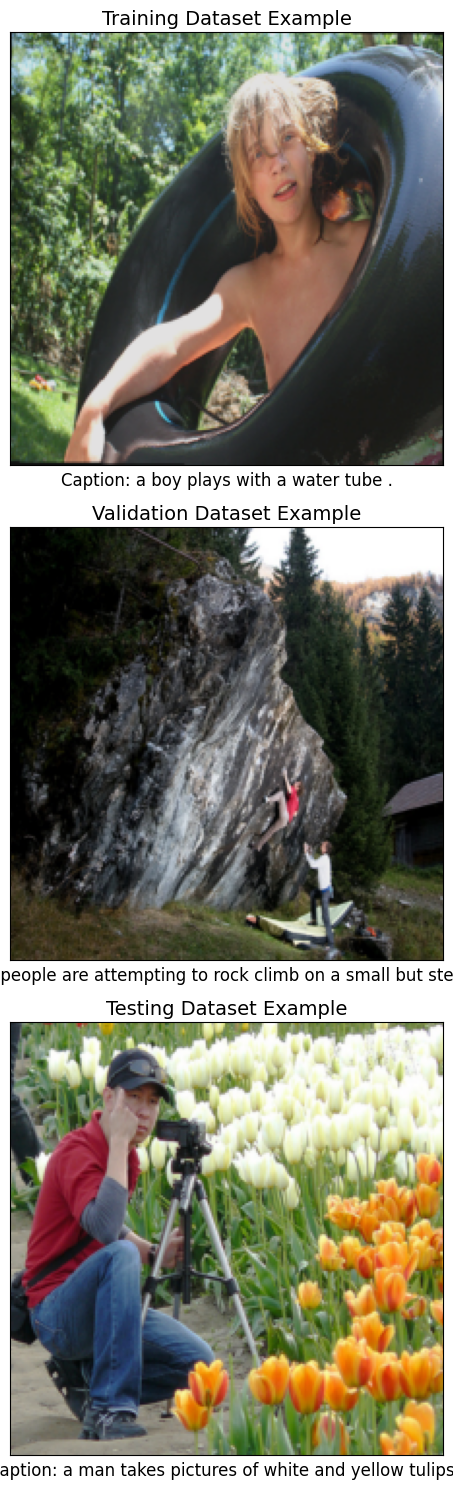

In [ ]:
def show_dataset_examples():
    plt.figure(figsize=(15, 5*3))
    
    # Function to convert tensor image back for display
    '''
        example of the tensor_to_img function:
        tensor = torch.randn(3, 224, 224)  # Random tensor simulating an image
        img = tensor_to_img(tensor)
        img.show()  # Display the image
    '''
    def tensor_to_img(tensor):
        # Unnormalize
        invTrans = transforms.Compose([
            transforms.Normalize(mean=[0, 0, 0], std=[1/0.229, 1/0.224, 1/0.225]),
            transforms.Normalize(mean=[-0.485, -0.456, -0.406], std=[1, 1, 1]),
            transforms.ToPILImage()
        ])
        return invTrans(tensor.cpu().clone())
    
    # Function to convert indices back to words
    '''
    example of the indices_to_caption function:
        indices = torch.tensor([1, 12, 34, 56, 2])
        vocab = Vocabulary()
        vocab.stoi = {"<sos>": 1, "<eos>": 2, "a": 12, "cat": 34, "sits": 56}
        vocab.itos = {1: "<sos>", 2: "<eos>", 12: "a", 34: "cat", 56: "sits"}
        caption = indices_to_caption(indices, vocab)
        print(caption)  # Output: "a cat sits"
    '''
    def indices_to_caption(indices, vocab):
        words = []
        for idx in indices:
            if idx.item() == vocab.stoi["<eos>"]:
                break
            if idx.item() not in [vocab.stoi["<sos>"], vocab.stoi["<pad>"]]:
                words.append(vocab.itos[idx.item()])
        return " ".join(words)
    
    # Show example from each dataset
    datasets = [train_dataset, val_dataset, test_dataset]
    names = ["Training", "Validation", "Testing"]
    
    for i, (dataset, name) in enumerate(zip(datasets, names)):
        idx = random.randint(0, len(dataset)-1)
        image, caption_indices, length = dataset[idx]
        
        # Convert caption indices back to words
        caption_text = indices_to_caption(caption_indices, vocab)
        
        plt.subplot(3, 1, i+1)
        plt.imshow(tensor_to_img(image))
        plt.title(f"{name} Dataset Example", fontsize=14)
        plt.xlabel(f"Caption: {caption_text}", fontsize=12)
        plt.xticks([])
        plt.yticks([])
    
    plt.tight_layout()
    plt.show()

# Display examples from each dataset
show_dataset_examples()

The **data loaders** in PyTorch are used to efficiently load and batch data for training, validation, and testing. They handle tasks like shuffling, batching, and parallel data loading, making it easier to work with datasets.

A **data loader** is an iterator that provides batches of data from a dataset. It works with the dataset class `FlickrDataset` and applies batching, shuffling, and other operations to prepare the data for the model.


### `collate_fn` 
The `collate_fn` function is used to handle variable-length captions. Since captions can have different lengths, they need to be padded to the same length within a batch
1. Sorts the batch by caption length (descending).
2. Stacks the images into a single tensor.
3. Pads the captions to the length of the longest caption in the batch.

This ensures that all captions in a batch have the same length, which is required for efficient processing by the model.

Normally, PyTorch’s `DataLoader` batches samples like this:

```python
(images, captions, lengths)
(images, captions, lengths)
...
```

But when **captions have different lengths**, it can’t just stack them — we need to **pad them** manually. That’s where the custom `collate_fn` comes in.

---
## **collate_fn exmaplanation :**
#### 1. **Sort by caption length**
```python
batch.sort(key=lambda x: x[2], reverse=True)
```
---

#### 2. **Unpack batch**
```python
images, captions, lengths = zip(*batch)
```
we get:
- `images`: list of tensors
- `captions`: list of 1D caption tensors (different lengths)
- `lengths`: lengths of each caption

---

#### 3. **Stack images**
```python
images = torch.stack(images, 0)
```
Now we have a tensor of shape `[batch_size, 3, 224, 224]`

---

#### 4. **Pad the captions**
```python
padded_captions = torch.zeros(len(captions), max_length).long()
```
- we create a tensor of zeros `[batch_size, max_caption_length]`
- Then fill each row with the actual caption, padded with 0s

---

#### 5. **Return**
```python
return images, padded_captions, torch.tensor(lengths)
```

we return:
- Batched images: `[B, C, H, W]`
- Padded captions: `[B, max_len]`
- Lengths: used in loss masking or sequence packing

---

### **without this step : the model would **crash** or get bad training, because tensors with varying shapes can't be batched automatically.**
This is a classic trick in any NLP + vision mix task like image captioning. we always need:
- custom `collate_fn`
- `pad_sequence` or manual padding
- lengths for masking or `pack_padded_sequence`


In [ ]:
# Collate function to handle variable caption lengths
def collate_fn(batch):
    # Sort batch by caption length (descending)
    batch.sort(key=lambda x: x[2], reverse=True)
    images, captions, lengths = zip(*batch)
    
    # Stack images
    images = torch.stack(images, 0)
    
    # Pad captions to the length of the longest caption
    max_length = max(lengths)
    padded_captions = torch.zeros(len(captions), max_length).long()
    
    # Fill in the padded captions tensor
    for i, cap in enumerate(captions):
        end = lengths[i]
        padded_captions[i, :end] = cap[:end]
    
    return images, padded_captions, torch.tensor(lengths)

# batch_size = 64 
# batch_size = 32
batch_size = 16

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=collate_fn,
    # num_workers=2,  
    num_workers=1,  
    pin_memory=False  # Disable if running on CPU
) 

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_fn,
    # num_workers=4,
    num_workers=1,
    pin_memory=True
)
test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_fn
    num_workers=1,
    Pin_memory=True
)

''' 
example of the data loader usage:
**example** showing what the `DataLoader` would return using the `collate_fn`, 
including how the `images`, `captions`, and `lengths` would look like :

---

###  First, mock a small batch manually

Let’s assume this is what `train_dataset[0:2]` gives:

```python
# (images, captions, lengths) this is the sample shape

sample_1 = (torch.rand(3, 224, 224), torch.tensor([1, 4, 5, 6, 2]), 5)  # caption length 5
sample_2 = (torch.rand(3, 224, 224), torch.tensor([1, 7, 8, 2]), 4)     # caption length 4

batch = [sample_1, sample_2]
```

---

###  Apply `collate_fn(batch)`

```python
images, captions, lengths = collate_fn(batch)
```

- Sort by caption length: `sample_1` stays first, `sample_2` second
- Max length = 5
- Pad `sample_2`'s caption to length 5 → `[1, 7, 8, 2, 0]`

---

###  Output

```python
>>> images.shape
torch.Size([2, 3, 224, 224])   # 2 images stacked
# - There are 2 images in the batch.
# - Each image is 3 channels, 224x224 pixels.

>>> captions
tensor([
    [1, 4, 5, 6, 2],   # sample_1 (original length 5)
    [1, 7, 8, 2, 0]    # sample_2 padded to match
])

#sample_1 had a caption of length 5: [1, 4, 5, 6, 2]
#sample_2 had a shorter caption: [1, 7, 8, 2], so we added a 0 at the end to pad it to the same length (5).
#The 0 here is the index of <pad> in the vocab.

>>> lengths
tensor([5, 4])

This keeps the real lengths before padding:
So the model knows where the actual caption ends and padding starts.
This is useful in attention masks to ignore the <pad> tokens.

'''

To calculate the total number of batches:

1. From the dataset split:
   - The dataset contains 8,000 images with 5 captions each
   - 70% train (5,600 images), 15% validation (1,200 images), 15% test (1,200 images)
   - Each image has 5 captions, so the train dataset has approximately 28,000 image-caption pairs

2. Number of batches:
   - Training batches = 28,000 ÷ 16 ≈ **1,750 batches**
   - Validation batches = 6,000 ÷ 16 ≈ **375 batches**
   - Test batches = 6,000 ÷ 16 ≈ **375 batches**


**Each batch will contain 16 image-caption pairs — not 16 unique images, but 16 pairs. Since each image is repeated 5 times (for each caption), the loader samples those pairs.**



**visualize a batch from our train loader to ensure everything is working correctly.**

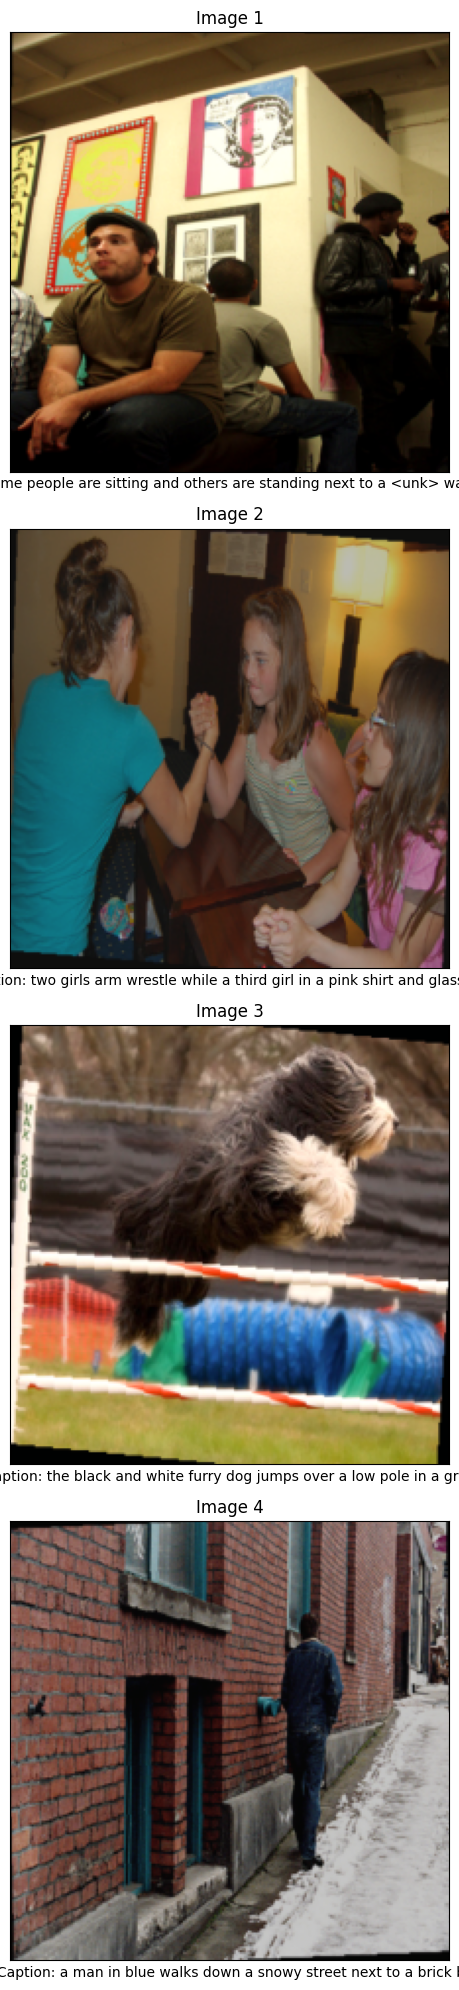

In [ ]:
# Creates an iterator over the train_loader (which contains ~1,750 batches).
# The `next()` function retrieves the first batch from this iterator.
# This batch contains 16 samples (images, captions, and their lengths).
images, captions, lengths = next(iter(train_loader)) 

# Display a few images with their captions
def visualize_batch(images, captions, lengths, vocab, num_examples=4):
    plt.figure(figsize=(15, 5*num_examples))
    
    # Define inverse transform to unnormalize images
    inv_normalize = transforms.Compose([
        transforms.Normalize(
            mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
            std=[1/0.229, 1/0.224, 1/0.225]
        )
    ])
    
    for i in range(min(num_examples, len(images))):
        # Unnormalize and convert image to numpy array
        img = inv_normalize(images[i]).permute(1, 2, 0).clamp(0, 1).numpy()
        
        # Decode caption
        cap_length = lengths[i].item()
        cap = captions[i][:cap_length].tolist()
        decoded_caption = " ".join([vocab.itos[idx] for idx in cap 
                                  if idx not in [vocab.stoi["<sos>"], vocab.stoi["<eos>"], vocab.stoi["<pad>"]]])
        
        # Display image and caption
        plt.subplot(num_examples, 1, i+1)
        plt.imshow(img)
        plt.title(f"Image {i+1}")
        plt.xlabel(f"Original Caption: {decoded_caption}")
        plt.xticks([])
        plt.yticks([])
    
    plt.tight_layout()
    plt.show()

# Visualize a batch
visualize_batch(images, captions, lengths, vocab, num_examples=4)

## What Happens Before Training: From Images to Data Processing Pipeline

the entire preprocessing flow from raw data to model-ready batches in the code:

### 1. Loading the Raw Data

First, the load images and captions from the Flickr8k dataset:
- Images are stored in the `IMAGES_DIR` 
- Captions are in a text file `CAPTIONS_FILE`
-  parse this into a dictionary `all_captions` where:
  - Keys are image filenames
  - Values are lists of 5 captions per image

### 2. Vocabulary Building

the `Vocabulary` class builds a mapping between words and indices:

```python 
vocab = Vocabulary(freq_threshold=10)
vocab.build_vocabulary(all_captions)
```

This:
1. Counts word frequencies across all captions
2. Only includes words appearing at least 10 times (`freq_threshold=10`)
3. Creates two dictionaries:
   - `stoi`: Maps words to indices (e.g., "dog" → 5)
   - `itos`: Maps indices to words (e.g., 5 → "dog")
4. Adds special tokens: `<pad>`, `<sos>`, `<eos>`, `<unk>`

**The `<unk>` token is crucial** - any word not appearing at least 10 times gets replaced with `<unk>` during numericalization in the Dataset Creation 

### 3. Dataset Creation

the `FlickrDataset` class:
1. Splits data (70% train, 15% validation, 15% test)
2. Applies transforms to images (resizing, normalization)
3. **Converts captions to numerical form**


**This is where words get replaced with `<unk>`** - the `numericalize` method replaces any infrequent word (appearing less than 10 times) with the `<unk>` token index.

### 4. Data Loading and Batching

the `DataLoader` with the custom `collate_fn` manages batches:
```python 
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=collate_fn
)
  ```


The `collate_fn`:
1. Sorts samples by caption length
2. **Stacks images into a tensor of shape `[batch_size, 3, 224, 224]`**
3. Pads captions to equal length with `<pad>` tokens
---
### Summary

The process from raw data to training-ready batches is:
1. **Raw data**: Images + text captions
2. **Vocabulary**: Words → indices, with infrequent words as `<unk>`
3. **Dataset**: Converts each (image, caption) pair into (tensor, numericalized_caption)


4. **DataLoader**: Creates batches with padding for efficient training  
  - Images are stacked into a tensor of shape `[batch_size, 3, 224, 224]`  
  - Captions are padded to the same length and stacked into a tensor of shape `[batch_size, max_caption_length]`  
  - Lengths of captions are stored in a tensor of shape `[batch_size]`

`<unk>` in captions is because the `Vocabulary.numericalize()` method replaced infrequent words with the `<unk>` token. 

###  Final Flow Summary

```
Raw Image + Text Caption
     ↓
Tokenize & Clean Text
     ↓
Build Vocabulary (with freq threshold)
     ↓
Numericalize Captions
     ↓
Apply Image Transforms
     ↓
Wrap with Dataset
     ↓
Wrap Dataset with DataLoader + collate_fn
     ↓
Each Batch: (images, captions, lengths)
```

Ready to be fed into the **encoder-decoder model** 


## 5. Create Image Captioning Model

create our image captioning model with these components:
1. Encoder (CNN): Extracts features from images
2. Attention: Helps the model focus on relevant parts of the image
3. Decoder (LSTM): Generates captions based on image features

The overall architecture follows the Encoder-Attention-Decoder pattern.


After we've processed the data into batches with tensors, here's what gonna happens during model training:

1. **Encoder Stage**:
   ```python
   # Images go through ResNet-50 for feature extraction
   encoder_out = self.encoder(images)  # (batch_size, num_pixels, encoder_dim)
   ```
   - the ResNet encoder extracts 2048-dimensional features from each image
   - Output shape: `[batch_size, num_pixels, 2048]` where num_pixels = 49 (7×7 grid)

2. **Decoder Forward Pass with Attention**:
   ```python
   scores, caps_sorted, decode_lengths, alphas = self.decoder(encoder_out, captions, caption_lengths)
   ```
   - Takes image features and captions as input
   - For each time step (word position):
     - Calculates attention weights for different image regions
     - Uses LSTM to predict the next word
     - Stores attention weights for visualization

3. **Loss Calculation**:
   ```python
   # Calculate CrossEntropyLoss between predicted and actual words
   loss = criterion(scores_packed, targets_packed)
   # Add attention regularization (to make attention more focused)
   loss += 0.01 * attention_regularization
   ```

4. **Backpropagation**:
   ```python
   loss.backward()
   optimizer.step()
   ```
   - Gradients flow back through the network
   - Optimizer updates the weights

## 6. Model Evaluation

During validation or testing:

1. **Caption Generation**:
   ```python
   predicted_caption, alphas = model.caption_image(image, vocab)
   ```
   - The model takes an image and generates a caption word by word
   - Each word prediction uses attention to focus on relevant image regions
   - Returns both the caption and attention weights

2. **BLEU Score Calculation**:
   ```python
   bleu = sentence_bleu([reference_caption], predicted_caption, 
                        smoothing_function=SmoothingFunction().method1)
   ```
   - Measures how close the generated caption is to reference caption(s)

## 7. Model Comparison

You compare the custom model against a pretrained ViT-GPT2 model:

1. **Model Loading**:
   ```python
   pretrained_model = VisionEncoderDecoderModel.from_pretrained(
       "nlpconnect/vit-gpt2-image-captioning")
   ```

2. **Side-by-Side Comparison**:
   - the custom model with attention maps
   - Pretrained model's predictions
   - BLEU score comparison between both models
   
**The complete pipeline from preprocessing to user interaction creates a full image captioning system with both custom and pretrained models, showing how attention helps connect visual and textual information.**

In [ ]:
class Encoder(nn.Module):
    '''
        The `Encoder` is a CNN-based feature extractor. 
        extracting spatial visual features from images — 
        it transforms raw image tensors into meaningful feature vectors that the decoder can use to generate captions.

        turning each image into 49 spatial feature vectors, each 2048-dimensional.
        Each vector is like a "summary" of a patch of the image — now the decoder can attend to them individually.
        This is exactly what the attention mechanism in image captioning will use.


        Raw Image  `(batch_size, 3, 224, 224)` 
        CNN Features (before pooling)  `(batch_size, 2048, H', W')` 
        After Adaptive Pool  `(batch_size, 2048, 7, 7)` 
        After Permute  `(batch_size, 7, 7, 2048)` 
        Final Encoder Output  `(batch_size, 49, 2048)` 

        This final tensor is now ready to be input into the decoder + attention mechanism 
    '''
    # def __init__(self, encoded_image_size=14):
    def __init__(self, encoded_image_size=7):
        super(Encoder, self).__init__()
        # Use ResNet-50 as the backbone pretrained on ImageNet
        self.resnet = torchvision.models.resnet50(weights="IMAGENET1K_V1")
        
        # Removes the final classification layer (so we don’t get class logits)
        modules = list(self.resnet.children())[:-2]
        self.resnet = nn.Sequential(*modules)
        
        # Fine-tune only the last two blocks of ResNet
        for param in list(self.resnet.parameters())[:-36]:  # Freeze earlier layers
            param.requires_grad = False
            
        # Adaptive pooling to get fixed size output
        self.adaptive_pool = nn.AdaptiveAvgPool2d((encoded_image_size, encoded_image_size))
        
    def forward(self, images):
        # input images: (batch_size, 3, height, width)
        features = self.resnet(images)  # (batch_size, 2048, h, w) h and w usually 7 or 14

        # Force features to shape (batch_size, 2048, 7, 7) regardless of input image size
        features = self.adaptive_pool(features)  

        # `(batch_size, 7, 7, 2048)` → moves channel to the end so each pixel is a 2048-dim vector
        features = features.permute(0, 2, 3, 1)  
        
        #- Flatten spatial dimensions (7x7 → 49 patches):
        #- → Final output: `(batch_size, 49, 2048)`
        batch_size = features.size(0)
        features = features.view(batch_size, -1, features.size(-1))  # (batch_size, encoded_image_size*encoded_image_size, 2048)
        
        return features

'''
    For each image in the batch, the encoder produces:
    - 49 spatial regions of interest
    - Each region is turned into a 2048-dim vector (feature)
    These vectors don’t represent the whole image — each one represents a patch.
    This lets the decoder later "look at" (attend to) different regions when generating words in the caption.
'''

In [ ]:
class Attention(nn.Module):
    '''
        - Computes attention weights for each of the 49 image regions
        - Three linear layers calculate relevance scores between text and image
        - Uses soft attention (softmax) to create a weighted sum of visual features


        Inputs:
        - encoder_out: shape (batch_size, 49, 2048) — the 49 visual vectors from the Encoder
        - decoder_hidden: shape (batch_size, decoder_dim) — the hidden state from the LSTM at current time step

        1. Linear transforms:
        - `att1 = W1 × encoder_out` → shape `(batch, 49, attention_dim)`
        - `att2 = W2 × decoder_hidden` → shape `(batch, 1, attention_dim)`

        2. Add + ReLU  
        `att = ReLU(att1 + att2)` → broadcast add over 49 patches

        3. Get attention scores:  
        `score = W3 × att` → shape `(batch, 49)`

        4. Softmax:  
        Turns scores into probabilities (attention weights):  
        `alpha = softmax(score)` → shape `(batch, 49)`

        5. Weighted sum of visual features (context vector):  
        `context = sum(alpha_i × encoder_out_i)` → shape `(batch, 2048)`


          Outputs:
        - `context`: shape `(batch, 2048)` — what the decoder will use now
        - `alpha`: shape `(batch, 49)` — tells us *where* the model is focusing in the image


  '''
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super(Attention, self).__init__()
        
        self.encoder_att = nn.Linear(encoder_dim, attention_dim)  # Linear layer for encoder features
        self.decoder_att = nn.Linear(decoder_dim, attention_dim)  # Linear layer for decoder hidden state
        self.full_att = nn.Linear(attention_dim, 1)  # Linear layer to compute attention weights
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)
        
    def forward(self, encoder_out, decoder_hidden):
        # encoder_out: (batch_size, num_pixels, encoder_dim)
        # decoder_hidden: (batch_size, decoder_dim)
        
        att1 = self.encoder_att(encoder_out)  # (batch_size, num_pixels, attention_dim)
        att2 = self.decoder_att(decoder_hidden).unsqueeze(1)  # (batch_size, 1, attention_dim)
        
        att = self.relu(att1 + att2)  # (batch_size, num_pixels, attention_dim)
        att = self.full_att(att).squeeze(2)  # (batch_size, num_pixels)
        alpha = self.softmax(att)  # (batch_size, num_pixels)
        
        # Weighted sum of encoder outputs
        context = (encoder_out * alpha.unsqueeze(2)).sum(dim=1)  # (batch_size, encoder_dim)
        
        return context, alpha

In [ ]:
class DecoderWithAttention(nn.Module):
    '''
        The DecoderWithAttention class is a recurrent neural network (RNN) decoder with attention mechanism.
        It generates captions for images by attending to different parts of the image at each time step.
        The attention mechanism allows the decoder to focus on specific regions of the image while generating each word in the caption.
'''
    def __init__(self, attention_dim, embed_dim, decoder_dim, vocab_size, encoder_dim=2048, dropout=0.5):
        super(DecoderWithAttention, self).__init__()
        
        self.encoder_dim = encoder_dim
        self.attention_dim = attention_dim
        self.embed_dim = embed_dim
        self.decoder_dim = decoder_dim
        self.vocab_size = vocab_size
        
        # Attention network
        self.attention = Attention(encoder_dim, decoder_dim, attention_dim)
        
        # Embedding layer to embed input tokens
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        
        # Dropout layer
        self.dropout = nn.Dropout(p=dropout)
        
        # LSTM decoder
        self.lstm = nn.LSTMCell(embed_dim + encoder_dim, decoder_dim)
        
        # Linear layer to find initial hidden and cell states of LSTM
        self.init_h = nn.Linear(encoder_dim, decoder_dim)
        self.init_c = nn.Linear(encoder_dim, decoder_dim)
        
        # Linear layer to produce initial input for LSTM
        self.f_beta = nn.Linear(decoder_dim, encoder_dim)
        self.sigmoid = nn.Sigmoid()
        
        # Linear layer to produce vocabulary scores
        self.fc = nn.Linear(decoder_dim, vocab_size)
        
        # Initialize weights
        self.init_weights()
    
    def init_weights(self):
        # Initialize embedding layer weights
        self.embedding.weight.data.uniform_(-0.1, 0.1)
        
        # Initialize linear layers weights
        self.fc.bias.data.fill_(0)
        self.fc.weight.data.uniform_(-0.1, 0.1)
    
    def init_hidden_state(self, encoder_out):
        # Initialize hidden and cell states
        mean_encoder_out = encoder_out.mean(dim=1)  # (batch_size, encoder_dim)
        h = self.init_h(mean_encoder_out)  # (batch_size, decoder_dim)
        c = self.init_c(mean_encoder_out)  # (batch_size, decoder_dim)
        return h, c
    
    def forward(self, encoder_out, encoded_captions, caption_lengths):
        """
        Forward propagation.
        
        encoder_out: encoded images, tensor of dimension (batch_size, num_pixels, encoder_dim)
        encoded_captions: encoded captions, tensor of dimension (batch_size, max_caption_length)
        caption_lengths: caption lengths, tensor of dimension (batch_size)
        """
        
        batch_size = encoder_out.size(0)
        num_pixels = encoder_out.size(1)
        
        # Sort input data by decreasing caption lengths
        caption_lengths, sort_ind = caption_lengths.sort(dim=0, descending=True)
        encoder_out = encoder_out[sort_ind]
        encoded_captions = encoded_captions[sort_ind]
        
        # Embedding
        embeddings = self.embedding(encoded_captions)  # (batch_size, max_caption_length, embed_dim)
        
        # Initialize hidden state and cell state
        h, c = self.init_hidden_state(encoder_out)  # (batch_size, decoder_dim)
        
        # Create tensors to hold word prediction scores and alphas
        max_length = max(caption_lengths)
        predictions = torch.zeros(batch_size, max_length, self.vocab_size).to(device)
        alphas = torch.zeros(batch_size, max_length, num_pixels).to(device)
        
        # At each time step:
        for t in range(max_length):
            batch_size_t = sum([l > t for l in caption_lengths])
            
            attention_weighted_encoding, alpha = self.attention(
                encoder_out[:batch_size_t], h[:batch_size_t]
            )
            
            gate = self.sigmoid(self.f_beta(h[:batch_size_t]))  # gating scalar, (batch_size_t, encoder_dim)
            attention_weighted_encoding = gate * attention_weighted_encoding
            
            # Get input for this time step (embedding and attention context)
            lstm_input = torch.cat(
                [embeddings[:batch_size_t, t, :], attention_weighted_encoding], dim=1
            )
            
            # Pass through LSTM
            h, c = self.lstm(
                lstm_input,
                (h[:batch_size_t], c[:batch_size_t])
            )
            
            # Compute output from hidden state
            preds = self.fc(self.dropout(h))  # (batch_size_t, vocab_size)
            predictions[:batch_size_t, t, :] = preds
            alphas[:batch_size_t, t, :] = alpha
        
        return predictions, encoded_captions, caption_lengths, alphas

In [ ]:
class EncoderDecoder(nn.Module):
    '''
        The EncoderDecoder class combines the Encoder and DecoderWithAttention classes.
        It takes an image as input, encodes it into a feature vector using the Encoder, and then generates a caption using the DecoderWithAttention.
        The attention mechanism allows the decoder to focus on different parts of the image while generating each word in the caption.
    '''
    def __init__(self, embed_size=256, vocab_size=1000, attention_dim=256, encoder_dim=2048, decoder_dim=512, dropout=0.5):
        super(EncoderDecoder, self).__init__()
        
        # Initialize the encoder
        self.encoder = Encoder()
        
        # Initialize the decoder with attention
        self.decoder = DecoderWithAttention(
            attention_dim=attention_dim,
            embed_dim=embed_size,
            decoder_dim=decoder_dim,
            vocab_size=vocab_size,
            encoder_dim=encoder_dim,
            dropout=dropout
        )
        
    def forward(self, images, captions, caption_lengths):
        # Forward pass through encoder to get image features
        encoder_out = self.encoder(images)  # (batch_size, num_pixels, encoder_dim)
        
        # Forward pass through decoder with attention using image features and captions
        scores, caps_sorted, decode_lengths, alphas = self.decoder(
            encoder_out, captions, caption_lengths
        )
        
        return scores, caps_sorted, decode_lengths, alphas
    
    
    def caption_image(self, image, vocabulary, max_length=50):
        """
        Generate a caption for a single image
        """
        # Set model to evaluation mode
        self.eval()
        
        with torch.no_grad():
            # Properly handle image dimensions
            if image.dim() == 3:  # [C, H, W]
                image = image.unsqueeze(0)  # Add batch dimension [1, C, H, W]
            
            # ensure image is on the correct device
            image = image.to(device)
                
            # Encode the image
            encoder_out = self.encoder(image)
            
            # Initialize hidden state and cell state
            h, c = self.decoder.init_hidden_state(encoder_out)
            
            # Start with <sos> token
            prev_word = torch.tensor([vocabulary.stoi['<sos>']]).to(device)
            
            # Lists to store predicted words and attention weights
            predicted_caption = []
            alphas = []
            
            # Generate caption word by word
            for i in range(max_length):
                # Embed the previous word and ensure correct dimensions
                embeddings = self.decoder.embedding(prev_word)  # [1, embed_dim]
                
                # Get attention weighted encoding
                attention_weighted_encoding, alpha = self.decoder.attention(encoder_out, h)
                
                # Save attention weights for visualization
                alphas.append(alpha)
                
                # Gate
                gate = self.decoder.sigmoid(self.decoder.f_beta(h))
                attention_weighted_encoding = gate * attention_weighted_encoding
                
                #  dimensions match before concatenation
                # embeddings shape should be [1, embed_dim]
                # attention_weighted_encoding should be [1, encoder_dim]
                if embeddings.dim() == 1:
                    embeddings = embeddings.unsqueeze(0)  # Add batch dimension
                if attention_weighted_encoding.dim() == 1:
                    attention_weighted_encoding = attention_weighted_encoding.unsqueeze(0)
                
                # LSTM forward pass with correct dimensions
                lstm_input = torch.cat([embeddings, attention_weighted_encoding], dim=1)
                h, c = self.decoder.lstm(lstm_input, (h, c))
                
                # Generate prediction
                scores = self.decoder.fc(self.decoder.dropout(h))
                prediction = scores.argmax(1)
                
                # Stop if <eos> token is generated
                if prediction.item() == vocabulary.stoi['<eos>']:
                    break
                
                # Add predicted word to caption
                predicted_caption.append(prediction.item())
                
                # Update previous word
                prev_word = prediction
            
            # Convert word indices to actual words
            predicted_words = [vocabulary.itos[idx] for idx in predicted_caption]
            
        return predicted_words, alphas

In [22]:
# Define loss function and optimizer
def initialize_training(model, learning_rate=3e-4):
    # Define loss function (CrossEntropyLoss ignores padding tokens)
    criterion = nn.CrossEntropyLoss(ignore_index=vocab.stoi['<pad>'])
    
    # Define optimizer (Adam works well for this task)
    optimizer = torch.optim.Adam(params=filter(lambda p: p.requires_grad, model.parameters()), 
                                lr=learning_rate)
    
    return criterion, optimizer

In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=3):
    # Move model to device
    model = model.to(device)
    
    # Create gradient scaler for mixed precision
    scaler = torch.amp.GradScaler('cuda') if use_amp else None
    
    # Training statistics
    train_losses = []
    val_losses = []
    val_bleu_scores = []
    best_val_loss = float('inf')
    patience = 5  # For early stopping
    counter = 0
    
    # Training loop
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        # Progress bar for training
        progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]')
        
        for images, captions, caption_lengths in progress_bar:
            # Move data to device
            images = images.to(device)
            captions = captions.to(device)
            caption_lengths = caption_lengths.to(device)
            
            # Zero the parameter gradients
            optimizer.zero_grad(set_to_none=True)  # More efficient than zero_grad()
            
            try:
                # Forward pass with autocast for mixed precision
                # with torch.cuda.amp.autocast(enabled=use_amp):
                with torch.cuda.amp.autocast(enabled=use_amp):
                    scores, caps_sorted, decode_lengths, alphas = model(images, captions, caption_lengths)
                    
                    # Calculate loss
                    targets = caps_sorted[:, 1:]  # Remove <sos> token
                    
                    # Move decode_lengths to CPU before packing
                    decode_lengths_cpu = decode_lengths.cpu()
                    
                    #  we use the minimum length between scores and targets
                    max_length = min(scores.size(1), targets.size(1))
                    
                    # Trim scores and targets to the same length
                    scores = scores[:, :max_length, :]
                    targets = targets[:, :max_length]
                    
                    # Also trim alphas to avoid out of bounds issues
                    alphas_trimmed = alphas[:, :max_length, :]
                    
                    # Use correct lengths -  they don't exceed the trimmed tensor dimensions
                    actual_lengths = [min(l.item(), max_length) for l in decode_lengths_cpu]
                    
                    scores_packed = pack_padded_sequence(scores, actual_lengths, batch_first=True).data
                    targets_packed = pack_padded_sequence(targets, actual_lengths, batch_first=True).data
                    
                    # Calculate loss
                    loss = criterion(scores_packed, targets_packed)
                    
                    # Add attention regularization - making sure we don't exceed dimensions
                    attention_regularization = 1. - (alphas_trimmed.sum(dim=1)).mean()
                    loss += 0.01 * attention_regularization
                
                # Backward pass and optimize with scaler if using mixed precision
                if use_amp:
                    scaler.scale(loss).backward()
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    optimizer.step()
                
                # Update training loss
                train_loss += loss.item()
                progress_bar.set_postfix(loss=loss.item())
                
            except RuntimeError as e:
                print(f"Error in training batch: {e}")
                print(f"Scores shape: {scores.shape}, Targets shape: {targets.shape}")
                print(f"Decode lengths: {decode_lengths_cpu}")
                continue
        
        # Calculate average training loss for this epoch
        train_loss = train_loss / len(train_loader)
        train_losses.append(train_loss)
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        bleu_scores = []
        
        with torch.no_grad():
            # Progress bar for validation
            progress_bar = tqdm(val_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Val]')
            
            for images, captions, caption_lengths in progress_bar:
                # Move data to device
                images = images.to(device)
                captions = captions.to(device)
                caption_lengths = caption_lengths.to(device)
                
                try:
                    # Forward pass (no autocast needed for validation since we're not training)
                    scores, caps_sorted, decode_lengths, alphas = model(images, captions, caption_lengths)
                    
                    # Calculate loss
                    targets = caps_sorted[:, 1:]  # Remove <sos> token
                    
                    # Move decode_lengths to CPU before packing
                    decode_lengths_cpu = decode_lengths.cpu()
                    
                    #  we use the minimum length between scores and targets
                    max_length = min(scores.size(1), targets.size(1))
                    
                    # Trim scores and targets to the same length
                    scores = scores[:, :max_length, :]
                    targets = targets[:, :max_length]
                    
                    # Also trim alphas to avoid out of bounds issues
                    alphas_trimmed = alphas[:, :max_length, :]
                    
                    # Use correct lengths -  they don't exceed the trimmed tensor dimensions
                    actual_lengths = [min(l.item(), max_length) for l in decode_lengths_cpu]
                    
                    # Pack scores and targets to handle variable length sequences
                    scores_packed = pack_padded_sequence(scores, actual_lengths, batch_first=True).data
                    targets_packed = pack_padded_sequence(targets, actual_lengths, batch_first=True).data
                    
                    # Calculate loss
                    loss = criterion(scores_packed, targets_packed)
                    
                    # Update validation loss
                    val_loss += loss.item()
                    progress_bar.set_postfix(loss=loss.item())
                    
                except RuntimeError as e:
                    print(f"Error in validation batch: {e}")
                    continue
                
                

                if len(bleu_scores) < 100:  # Limit to 100 samples for faster validation
                    try:
                        #  images has at least one element
                        if images.size(0) > 0:
                            # Get the first image from the batch
                            image_for_caption = images[0]  # This gives us [3, 224, 224]
                            
                            # FIXED: Generate caption correctly
                            pred_caption_tokens, _ = model.caption_image(image_for_caption, vocab)
                            
                            # Get the reference caption safely
                            ref_cap_indices = captions[0].cpu().tolist()
                            
                            # Filter out special tokens
                            ref_caption = []
                            for idx in ref_cap_indices:
                                if idx > 0:  # Skip padding tokens
                                    word = vocab.itos[idx]
                                    if word not in ['<sos>', '<eos>', '<pad>', '<unk>']:
                                        ref_caption.append(word)
                            
                            # Filter predicted caption
                            pred_caption = [w for w in pred_caption_tokens if w not in ['<sos>', '<eos>', '<pad>', '<unk>']]
                            
                            # Safely calculate BLEU score
                            if len(pred_caption) > 0 and len(ref_caption) > 0:
                                # bleu = sentence_bleu([ref_caption], pred_caption)
                                bleu = sentence_bleu([ref_caption], pred_caption, smoothing_function=SmoothingFunction().method1)
                                bleu_scores.append(bleu)
                    except Exception as e:
                        print(f"BLEU calculation error (non-critical): {str(e)}")
                        continue
        # Calculate average validation loss and BLEU score for this epoch
        val_loss = val_loss / len(val_loader) if len(val_loader) > 0 else float('inf')
        val_losses.append(val_loss)
        avg_bleu = sum(bleu_scores) / len(bleu_scores) if bleu_scores else 0
        val_bleu_scores.append(avg_bleu)
        
        # Print epoch statistics
        print(f'Epoch {epoch+1}/{num_epochs}:')
        print(f'  Training Loss: {train_loss:.4f}')
        print(f'  Validation Loss: {val_loss:.4f}')
        print(f'  Validation BLEU Score: {avg_bleu:.4f}')
        print(f'  Valid BLEU samples: {len(bleu_scores)}')
        
        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            counter = 0
            # Save the model
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'train_loss': train_loss,
                'val_loss': val_loss,
                'vocab': vocab
            }, 'best_model.pth')
            print("  Model saved!")
        else:
            counter += 1
            if counter >= patience:
                print(f"  Early stopping triggered after {patience} epochs without improvement")
                break
    
    return train_losses, val_losses, val_bleu_scores

In [ ]:
def plot_losses(train_losses, val_losses, val_bleu_scores):
    """
    Plot training metrics, with improved handling for single-epoch data
    """
    # Convert single values to lists if needed
    if not isinstance(train_losses, list):
        train_losses = [train_losses]
    if not isinstance(val_losses, list):
        val_losses = [val_losses]
    if not isinstance(val_bleu_scores, list):
        val_bleu_scores = [val_bleu_scores]
        
    # For single-epoch training, create a more meaningful x-axis
    if len(train_losses) == 1:
        # Create points for beginning and end of training
        epochs = [0, 1]
        train_data = [train_losses[0], train_losses[0]]
        val_data = [val_losses[0], val_losses[0]]
        bleu_data = [val_bleu_scores[0], val_bleu_scores[0]]
    else:
        epochs = range(1, len(train_losses) + 1)
        train_data = train_losses
        val_data = val_losses
        bleu_data = val_bleu_scores
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
    
    # Plot losses
    ax1.plot(epochs, train_data, 'b-o', label='Training Loss')
    ax1.plot(epochs, val_data, 'r-o', label='Validation Loss')
    ax1.set_title('Training and Validation Loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)
    
    # Plot BLEU scores
    ax2.plot(epochs, bleu_data, 'g-o', label='Validation BLEU Score')
    ax2.set_title('Validation BLEU Score')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('BLEU Score')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

In [ ]:
def plot_attention(image, caption, alphas):
    """
    Enhanced attention visualization function with better error handling and visualization
    """
    # Convert the image to a NumPy array for visualization
    img = image.permute(1, 2, 0).cpu().detach().numpy()
    img = (img * np.array([0.229, 0.224, 0.225])) + np.array([0.485, 0.456, 0.406])
    img = img.clip(0, 1)
    
    # Limit the number of words to display
    max_words_to_show = min(9, len(caption))
    
    # Calculate grid size based on number of words
    if max_words_to_show <= 3:
        rows, cols = 1, max_words_to_show + 1
    else:
        rows = (max_words_to_show + 1) // 4 + 1
        cols = min(4, max_words_to_show + 1)
    
    # Create figure with better styling
    plt.figure(figsize=(cols * 4, rows * 4))
    
    # Show the original image
    plt.subplot(rows, cols, 1)
    plt.imshow(img)
    plt.title('Original Image', fontsize=14)
    plt.axis('off')
    
    # Show the attention maps for each word
    for i in range(max_words_to_show):
        plt.subplot(rows, cols, i + 2)
        
        try:
            # Calculate attention size from the square root of tensor elements
            alpha = alphas[i].cpu().detach()
            attention_size = int(np.sqrt(alpha.numel()))
            
            # Reshape the attention weights to a square grid
            att_map = alpha.reshape(attention_size, attention_size).numpy()
            
            # Overlay attention map on the image with a more visible colormap
            plt.imshow(img)
            plt.imshow(att_map, alpha=0.7, cmap='hot')
            plt.title(caption[i], fontsize=14)
            plt.axis('off')
        except Exception as e:
            plt.text(0.5, 0.5, f"Error displaying\nattention for: {caption[i]}", 
                    ha='center', va='center', fontsize=10)
            plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Show full caption if truncated
    if len(caption) > max_words_to_show:
        print(f"Note: Only showing attention for {max_words_to_show} of {len(caption)} words.")
        print(f"Full caption: {' '.join(caption)}")

In [ ]:
def evaluate_model(model, test_loader, vocab, num_samples=10):
    # Set model to evaluation mode
    model.eval()
    
    # List to store BLEU scores
    bleu1_scores = []
    bleu2_scores = []
    bleu3_scores = []
    bleu4_scores = []
    
    # List to store example images, real captions, and generated captions
    examples = []
    
    # Define smoothing function once
    smooth = SmoothingFunction().method1
    
    with torch.no_grad():
        for i, (images, captions, lengths) in enumerate(tqdm(test_loader, desc="Evaluating")):
            if i >= num_samples:
                break
                
            # Move images to device
            images = images.to(device)
            
            # Generate caption
            for j, image in enumerate(images):
                # Generate caption
                predicted_caption, alphas = model.caption_image(image, vocab)
                
                # Remove special tokens from the generated caption
                predicted_caption = [word for word in predicted_caption if word not in ['<sos>', '<eos>', '<pad>']]
                
                # Get reference caption(s)
                reference_caption = [vocab.itos[idx.item()] for idx in captions[j][1:lengths[j]]]
                reference_caption = [word for word in reference_caption if word not in ['<sos>', '<eos>', '<pad>']]
                
                # Calculate BLEU scores with smoothing
                # bleu1 = sentence_bleu([reference_caption], predicted_caption, weights=(1, 0, 0, 0), smoothing_function=smooth)                
                # bleu2 = sentence_bleu([reference_caption], predicted_caption, weights=(0.5, 0.5, 0, 0), smoothing_function=smooth)
                # bleu3 = sentence_bleu([reference_caption], predicted_caption, weights=(0.33, 0.33, 0.33, 0), smoothing_function=smooth)
                # bleu4 = sentence_bleu([reference_caption], predicted_caption, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smooth)
                # Update in evaluate_model
                bleu1 = sentence_bleu([reference_caption], predicted_caption, weights=(1, 0, 0, 0), smoothing_function=smooth) if predicted_caption and reference_caption else 0
                bleu2 = sentence_bleu([reference_caption], predicted_caption, weights=(0.5, 0.5, 0, 0), smoothing_function=smooth) if predicted_caption and reference_caption else 0
                bleu3 = sentence_bleu([reference_caption], predicted_caption, weights=(0.33, 0.33, 0.33, 0), smoothing_function=smooth) if predicted_caption and reference_caption else 0
                bleu4 = sentence_bleu([reference_caption], predicted_caption, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smooth) if predicted_caption and reference_caption else 0
                
                
                bleu1_scores.append(bleu1)
                bleu2_scores.append(bleu2)
                bleu3_scores.append(bleu3)
                bleu4_scores.append(bleu4)
                
                # Store example
                examples.append({
                    'image': image,
                    'reference': ' '.join(reference_caption),
                    'prediction': ' '.join(predicted_caption),
                    'bleu1': bleu1,
                    'bleu2': bleu2,
                    'bleu3': bleu3,
                    'bleu4': bleu4,
                    'alphas': alphas
                })
    
    # Calculate average BLEU scores
    avg_bleu1 = sum(bleu1_scores) / len(bleu1_scores) if bleu1_scores else 0
    avg_bleu2 = sum(bleu2_scores) / len(bleu2_scores) if bleu2_scores else 0
    avg_bleu3 = sum(bleu3_scores) / len(bleu3_scores) if bleu3_scores else 0
    avg_bleu4 = sum(bleu4_scores) / len(bleu4_scores) if bleu4_scores else 0
    
    print(f"Average BLEU-1: {avg_bleu1:.4f}")
    print(f"Average BLEU-2: {avg_bleu2:.4f}")
    print(f"Average BLEU-3: {avg_bleu3:.4f}")
    print(f"Average BLEU-4: {avg_bleu4:.4f}")
    
    return examples, (avg_bleu1, avg_bleu2, avg_bleu3, avg_bleu4)

In [ ]:
def load_pretrained_model():
    """Load pretrained model with warning suppression"""
    
    # Suppress specific warnings
    warnings.filterwarnings("ignore", message="Config of the encoder.*is overwritten by shared encoder config")
    warnings.filterwarnings("ignore", message="Config of the decoder.*is overwritten by shared decoder config")
    transformers.logging.set_verbosity_error()  # Suppress most transformer warnings
    
    # Load model and processors
    model = VisionEncoderDecoderModel.from_pretrained("nlpconnect/vit-gpt2-image-captioning")
    image_processor = ViTImageProcessor.from_pretrained("nlpconnect/vit-gpt2-image-captioning")
    tokenizer = AutoTokenizer.from_pretrained("nlpconnect/vit-gpt2-image-captioning")
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    
    # Set model generation parameters
    model.config.decoder_start_token_id = tokenizer.bos_token_id
    model.config.pad_token_id = tokenizer.pad_token_id
    model.config.vocab_size = model.config.decoder.vocab_size
    
    # Set generation parameters - fix the conflicting parameters by enabling do_sample
    gen_kwargs = {
        "max_length": 20,
        "num_beams": 4,
        "do_sample": True,  # Changed to True to match with top_k
        "top_k": 30,
        "no_repeat_ngram_size": 2,
        "early_stopping": True,
    }
    
    return model, image_processor, tokenizer, gen_kwargs

In [ ]:
def evaluate_pretrained_model(model, image_processor, tokenizer, gen_kwargs, test_loader, num_samples=10):
    # List to store BLEU scores
    bleu1_scores = []
    bleu2_scores = []
    bleu3_scores = []
    bleu4_scores = []
    
    # List to store example images, real captions, and generated captions
    examples = []
    
    model.eval()
    with torch.no_grad():
        for i, (images, captions, lengths) in enumerate(tqdm(test_loader, desc="Evaluating Pretrained Model")):
            if i >= num_samples:
                break
                
            for j, image in enumerate(images):
                # Convert image to PIL format
                image_np = image.cpu().numpy().transpose(1, 2, 0)
                # De-normalize
                image_np = image_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
                image_np = (image_np * 255).astype(np.uint8)
                pil_image = Image.fromarray(image_np)
                
                # Preprocess image
                pixel_values = image_processor(pil_image, return_tensors="pt").pixel_values.to(device)
                
                # Generate caption
                output_ids = model.generate(pixel_values, **gen_kwargs)
                
                # Convert to text
                predicted_caption = tokenizer.decode(output_ids[0], skip_special_tokens=True)
                
                # Get reference caption
                reference_caption = [vocab.itos[idx.item()] for idx in captions[j][1:lengths[j]]]
                reference_caption = [word for word in reference_caption if word not in ['<sos>', '<eos>', '<pad>']]
                reference_text = ' '.join(reference_caption)
                
                # Convert prediction to list of words for BLEU calculation
                predicted_words = predicted_caption.lower().split()
                
                # Calculate BLEU scores
                smooth = SmoothingFunction().method1
                # bleu1 = sentence_bleu([reference_caption], predicted_words, weights=(1, 0, 0, 0), smoothing_function=smooth)                
                # bleu2 = sentence_bleu([reference_caption], predicted_words, weights=(0.5, 0.5, 0, 0))
                # bleu3 = sentence_bleu([reference_caption], predicted_words, weights=(0.33, 0.33, 0.33, 0))
                # bleu4 = sentence_bleu([reference_caption], predicted_words, weights=(0.25, 0.25, 0.25, 0.25))
                # Update in evaluate_pretrained_model
                bleu1 = sentence_bleu([reference_caption], predicted_words, weights=(1, 0, 0, 0), smoothing_function=smooth) if predicted_words and reference_caption else 0
                bleu2 = sentence_bleu([reference_caption], predicted_words, weights=(0.5, 0.5, 0, 0), smoothing_function=smooth) if predicted_words and reference_caption else 0
                bleu3 = sentence_bleu([reference_caption], predicted_words, weights=(0.33, 0.33, 0.33, 0), smoothing_function=smooth) if predicted_words and reference_caption else 0
                bleu4 = sentence_bleu([reference_caption], predicted_words, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smooth) if predicted_words and reference_caption else 0
                bleu1_scores.append(bleu1)
                bleu2_scores.append(bleu2)
                bleu3_scores.append(bleu3)
                bleu4_scores.append(bleu4)
                
                # Store example
                examples.append({
                    'image': image,
                    'reference': reference_text,
                    'prediction': predicted_caption,
                    'bleu1': bleu1,
                    'bleu2': bleu2,
                    'bleu3': bleu3,
                    'bleu4': bleu4
                })
    
    # Calculate average BLEU scores
    avg_bleu1 = sum(bleu1_scores) / len(bleu1_scores)
    avg_bleu2 = sum(bleu2_scores) / len(bleu2_scores)
    avg_bleu3 = sum(bleu3_scores) / len(bleu3_scores)
    avg_bleu4 = sum(bleu4_scores) / len(bleu4_scores)
    
    print(f"Pretrained Model:")
    print(f"Average BLEU-1: {avg_bleu1:.4f}")
    print(f"Average BLEU-2: {avg_bleu2:.4f}")
    print(f"Average BLEU-3: {avg_bleu3:.4f}")
    print(f"Average BLEU-4: {avg_bleu4:.4f}")
    
    return examples, (avg_bleu1, avg_bleu2, avg_bleu3, avg_bleu4)

In [ ]:
def compare_models(custom_data, pretrained_data, num_samples=5):
    """
    Improved function to compare custom and pretrained models with better visualization
    """
    # Unpack the data correctly
    custom_examples, custom_metrics = custom_data
    pretrained_examples, pretrained_metrics = pretrained_data
    
    # Create a list of indices to display, ensuring they're unique
    if isinstance(custom_examples, list):
        total_examples = min(len(custom_examples), len(pretrained_examples))
        if total_examples < num_samples:
            num_samples = total_examples
            print(f"Only {num_samples} examples available.")
            
        # Use random sampling without replacement
        indices = random.sample(range(total_examples), num_samples)
    else:
        # If not a list, just use sequential indices
        indices = range(min(num_samples, 1))
    
    print(f"Displaying {num_samples} random examples with indices: {indices}")
    
    # 1. First display side-by-side image comparisons
    for i, idx in enumerate(indices):
        # Setup the figure
        plt.figure(figsize=(15, 6))
        
        # Get the image
        image = custom_examples[idx]['image'] if isinstance(custom_examples, list) else custom_examples['image']
        img = image.permute(1, 2, 0).cpu().detach().numpy()
        img = (img * np.array([0.229, 0.224, 0.225])) + np.array([0.485, 0.456, 0.406])
        img = img.clip(0, 1)
        
        # Display the image
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Example {i+1} (Index: {idx})", fontsize=16)
        
        # Get the corresponding custom and pretrained examples
        custom_ex = custom_examples[idx] if isinstance(custom_examples, list) else custom_examples
        pretrained_ex = pretrained_examples[idx] if isinstance(pretrained_examples, list) else pretrained_examples
        
        # Create a formatted text block for captions
        text_block = (
            f"Reference caption:\n"
            f"➡️ {custom_ex['reference']}\n\n"
            f"Custom Model prediction (BLEU-1: {custom_ex['bleu1']:.3f}):\n"
            f"➡️ {custom_ex['prediction']}\n\n"
            f"Pretrained Model prediction (BLEU-1: {pretrained_ex['bleu1']:.3f}):\n"
            f"➡️ {pretrained_ex['prediction']}"
        )
        
        # Add the text block beneath the image
        plt.figtext(0.5, 0.01, text_block, ha='center', fontsize=13, 
                   bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=1'))
        
        plt.tight_layout()
        plt.subplots_adjust(bottom=0.35)  # Make room for text
        plt.show()
    
    # 2. Now show the metrics comparison chart
    metrics = ['BLEU-1', 'BLEU-2', 'BLEU-3', 'BLEU-4']
    
    # Create a DataFrame for easier plotting
    df = pd.DataFrame({
        'Metric': metrics,
        'Custom Model': custom_metrics,
        'Pretrained Model': pretrained_metrics
    })
    
    # Create a more attractive bar chart
    plt.figure(figsize=(12, 8))
    
    # Set bar positions
    x = np.arange(len(metrics))
    width = 0.35
    
    # Create bars with a more attractive style
    custom_bars = plt.bar(x - width/2, custom_metrics, width, label='Custom Model', 
                         color='#3498db', alpha=0.8, edgecolor='black', linewidth=1.5)
    pretrained_bars = plt.bar(x + width/2, pretrained_metrics, width, label='Pretrained Model', 
                             color='#e74c3c', alpha=0.8, edgecolor='black', linewidth=1.5)
    
    # Add value labels on bars
    for bars in [custom_bars, pretrained_bars]:
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                    f'{height:.4f}', ha='center', va='bottom', fontsize=11)
    
    # Customize chart
    plt.ylabel('Score', fontsize=14)
    plt.title('Performance Comparison: Custom vs. Pretrained Models', fontsize=16, pad=20)
    plt.xticks(x, metrics, fontsize=12)
    plt.yticks(fontsize=10)
    plt.ylim(0, max(max(custom_metrics), max(pretrained_metrics)) * 1.15)  # Add some headroom
    
    # Add a grid for better readability
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Add legend with better positioning
    plt.legend(loc='upper center', fontsize=12, frameon=True, facecolor='white', edgecolor='gray')
    
    # Add average BLEU score as text
    avg_custom = sum(custom_metrics) / len(custom_metrics)
    avg_pretrained = sum(pretrained_metrics) / len(pretrained_metrics)
    plt.figtext(0.15, 0.02, f"Custom Model Avg: {avg_custom:.4f}", fontsize=12)
    plt.figtext(0.65, 0.02, f"Pretrained Model Avg: {avg_pretrained:.4f}", fontsize=12)
    
    plt.tight_layout()
    plt.show()

In [ ]:
# # previously parameters 
# vocab_size = len(vocab)
# # embed_size = 256
# # attention_dim = 256
# # decoder_dim = 512

# encoder_dim = 2048
# dropout = 0.5

# # Reduce model dimensions
# embed_size = 128  
# attention_dim = 128  
# decoder_dim = 256  

In [ ]:

# Model architecture parameters
vocab_size = len(vocab) 
encoder_dim = 2048      

embed_size = 256        
attention_dim = 256    
decoder_dim = 512       
dropout = 0.5           

# Training parameters
batch_size = 16        
learning_rate = 1e-4    

print(f"Vocabulary size: {vocab_size}")

# Initialize model
model = EncoderDecoder(
    embed_size=embed_size,
    vocab_size=vocab_size,
    attention_dim=attention_dim,
    encoder_dim=encoder_dim,
    decoder_dim=decoder_dim,
    dropout=dropout
)

# Initialize loss function and optimizer
criterion, optimizer = initialize_training(model, learning_rate=3e-4)


Vocabulary size: 1918


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 197MB/s]


### **Train the model**

In [ ]:
train_losses, val_losses, val_bleu_scores = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    # num_epochs=30  
    # num_epochs=2  
    num_epochs=10
)

Epoch 1/2 [Train]:   0%|          | 0/1770 [00:00<?, ?it/s]

/tmp/ipykernel_31/466926715.py:37: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Epoch 1/2 [Val]:   0%|          | 0/380 [00:00<?, ?it/s]

Epoch 1/2:
  Training Loss: 3.9592
  Validation Loss: 3.3123
  Validation BLEU Score: 0.0348
  Valid BLEU samples: 100
  Model saved!


Epoch 2/2 [Train]:   0%|          | 0/1770 [00:00<?, ?it/s]

Epoch 2/2 [Val]:   0%|          | 0/380 [00:00<?, ?it/s]

Epoch 2/2:
  Training Loss: 3.2086
  Validation Loss: 3.0007
  Validation BLEU Score: 0.0445
  Valid BLEU samples: 100
  Model saved!


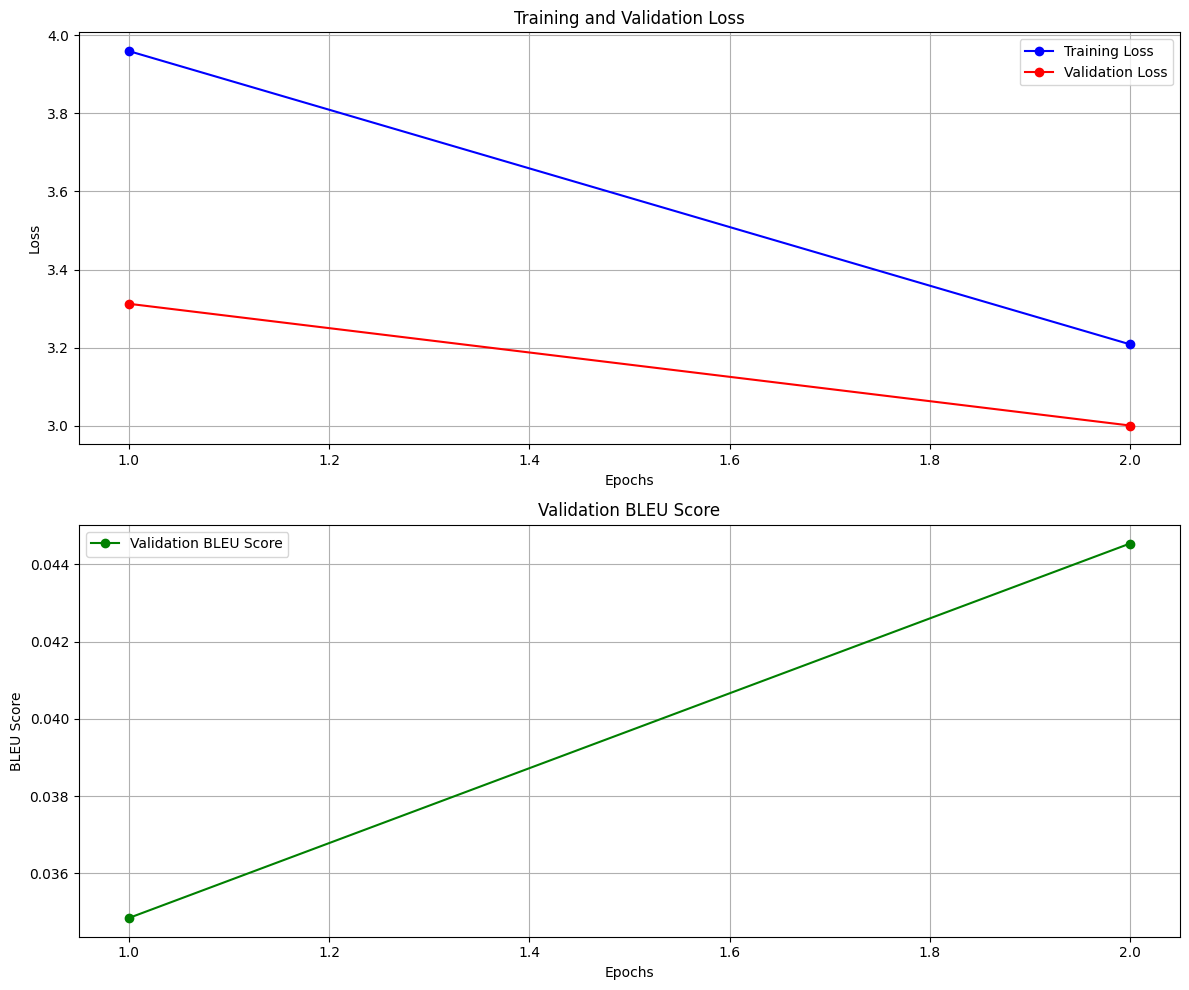

In [ ]:
# Visualize training metrics
plot_losses(train_losses, val_losses, val_bleu_scores)


**model evaluation**

In [33]:

# Load best model for evaluation
checkpoint = torch.load('best_model.pth', weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded model from epoch {checkpoint['epoch']} with validation loss {checkpoint['val_loss']:.4f}")

# Evaluate custom model
custom_examples, custom_metrics = evaluate_model(model, test_loader, vocab, num_samples=10)



Loaded model from epoch 1 with validation loss 3.0007


Evaluating:   0%|          | 0/380 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.11/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.11/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_

Average BLEU-1: 0.3359
Average BLEU-2: 0.1538
Average BLEU-3: 0.0623
Average BLEU-4: 0.0188


**Visualize attention for a sample**

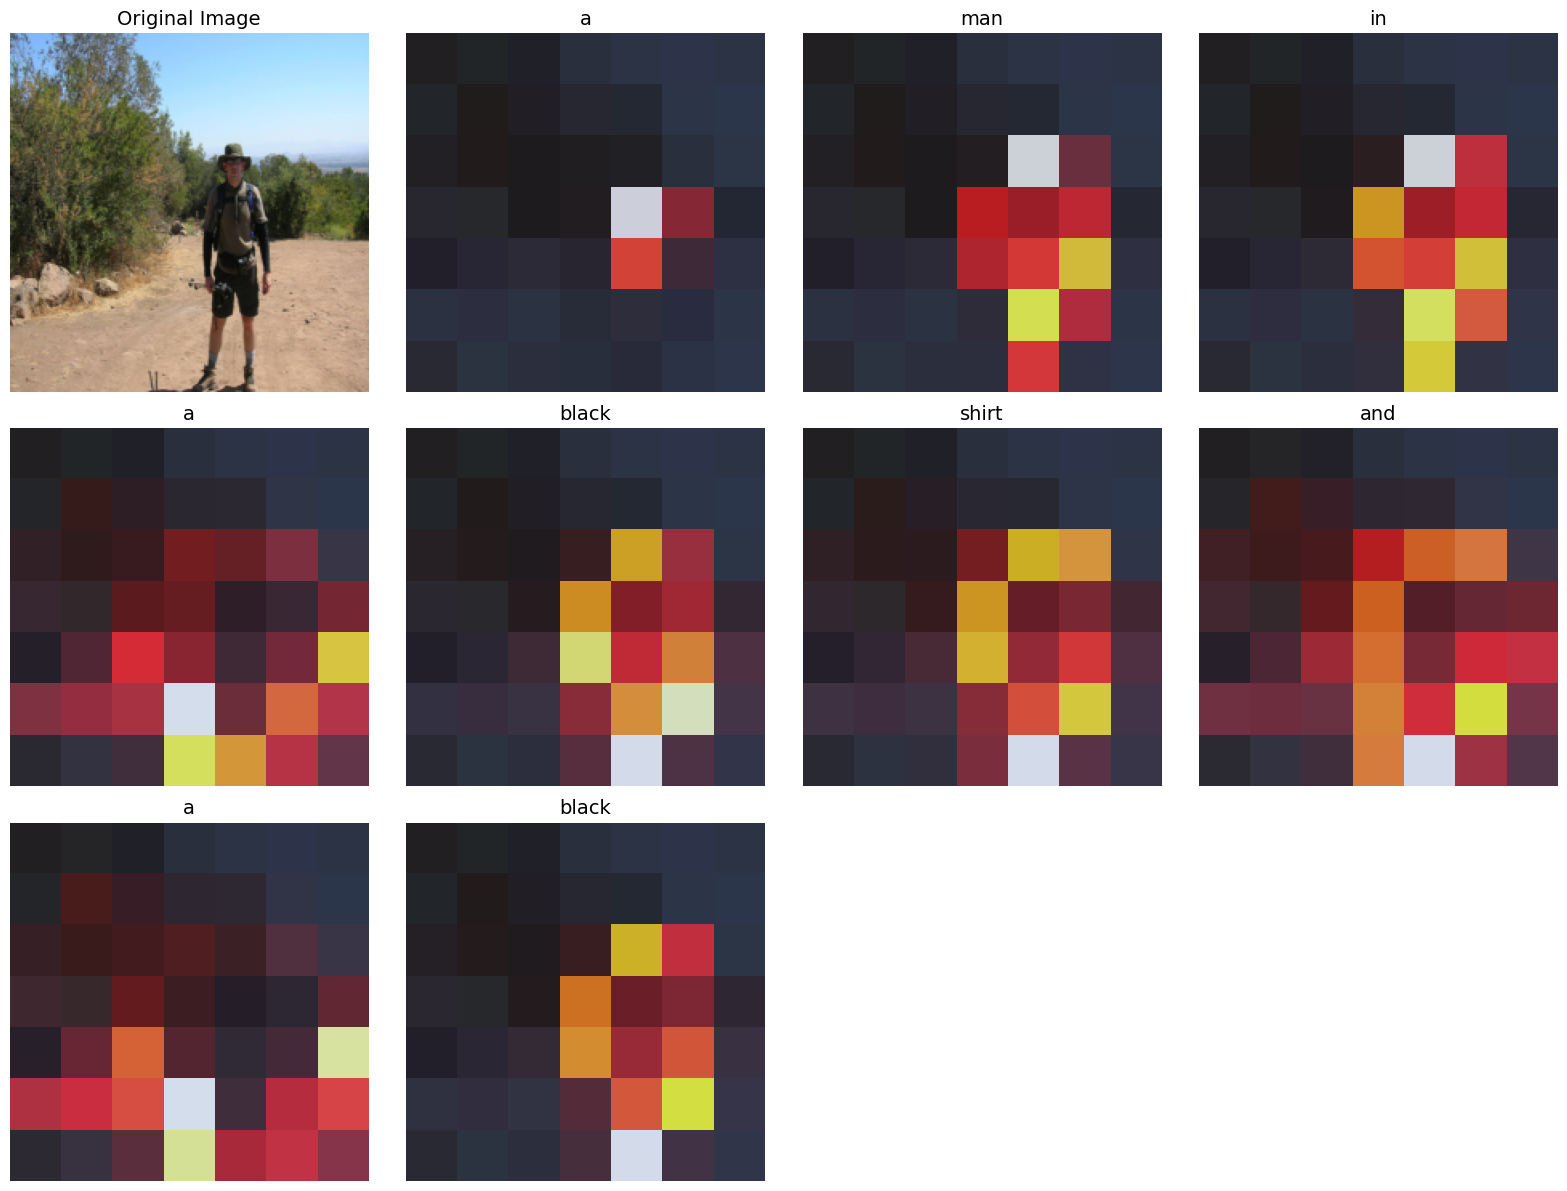

Note: Only showing attention for 9 of 11 words.
Full caption: a man in a black shirt and a black shirt and


In [34]:
sample = custom_examples[0]
image = sample['image']
caption = sample['prediction'].split()
#  we don't try to access more alphas than we have
alphas = sample['alphas'][:len(caption)]
# If caption is very long, limit it for visualization
if len(caption) > 11:
    caption = caption[:11]
    alphas = alphas[:11]
plot_attention(image, caption, alphas)


**Evaluate and Compare models**

config.json:   0%|          | 0.00/4.61k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


pytorch_model.bin:   0%|          | 0.00/982M [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/982M [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/120 [00:00<?, ?B/s]

Evaluating Pretrained Model:   0%|          | 0/380 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/transformers/generation/configuration_utils.py:653: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `30` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.11/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.11/dist-pack

Pretrained Model:
Average BLEU-1: 0.2937
Average BLEU-2: 0.1487
Average BLEU-3: 0.0703
Average BLEU-4: 0.0235


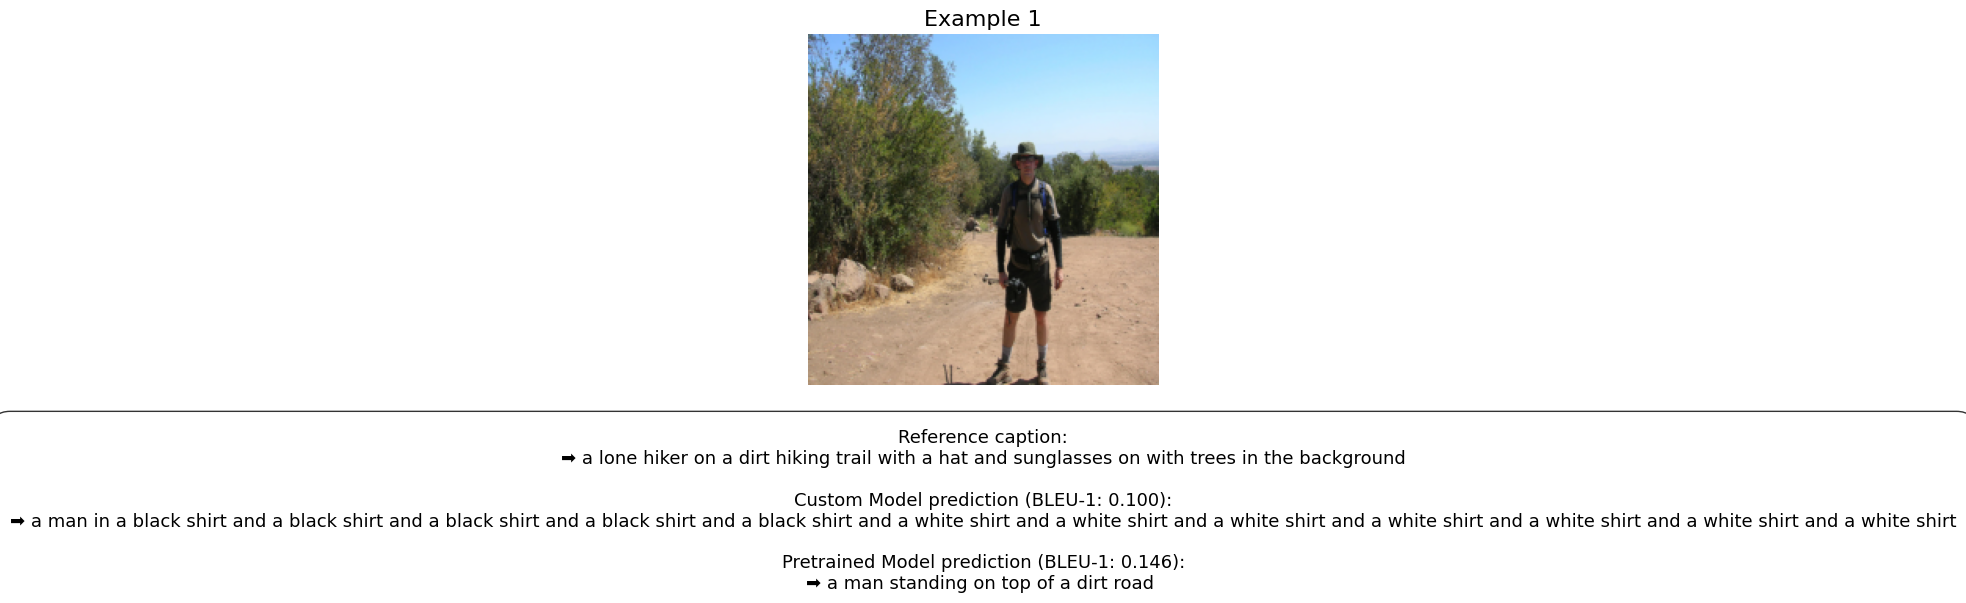

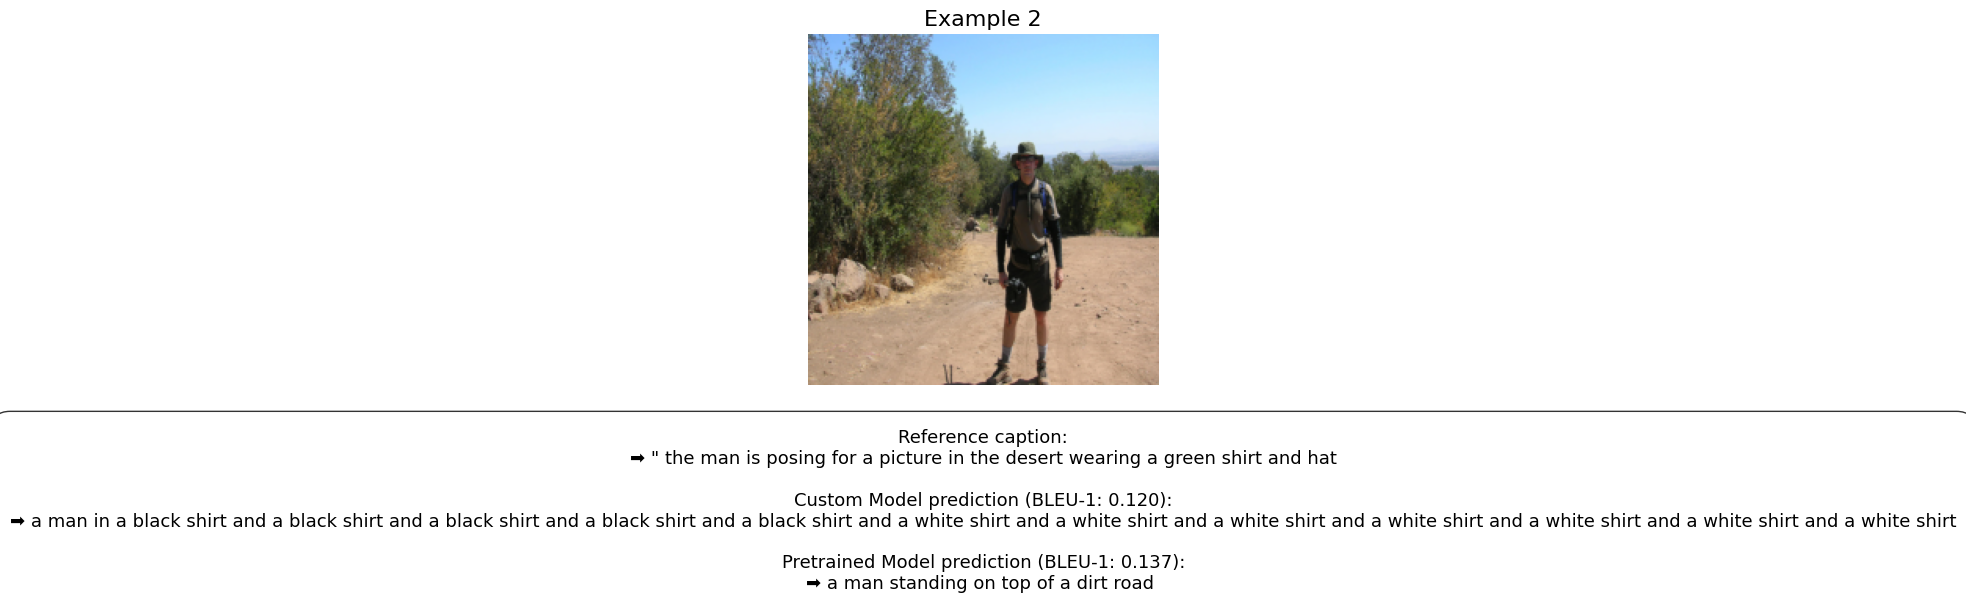

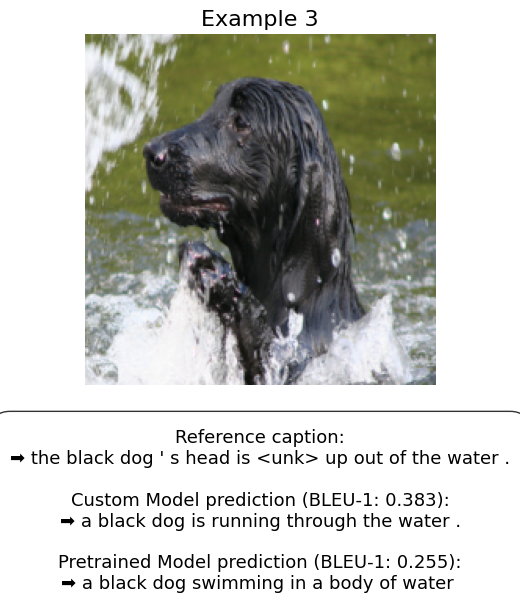

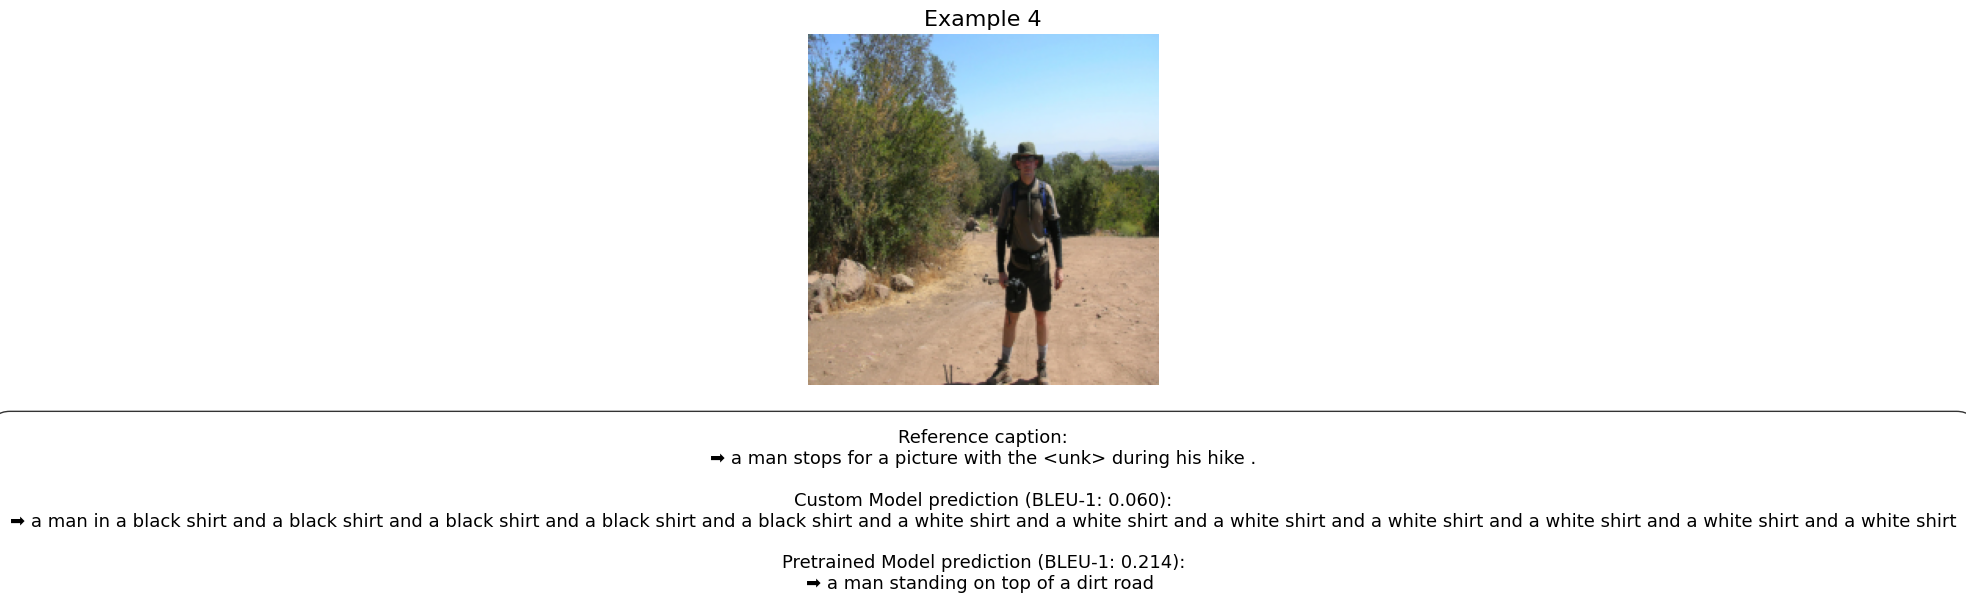

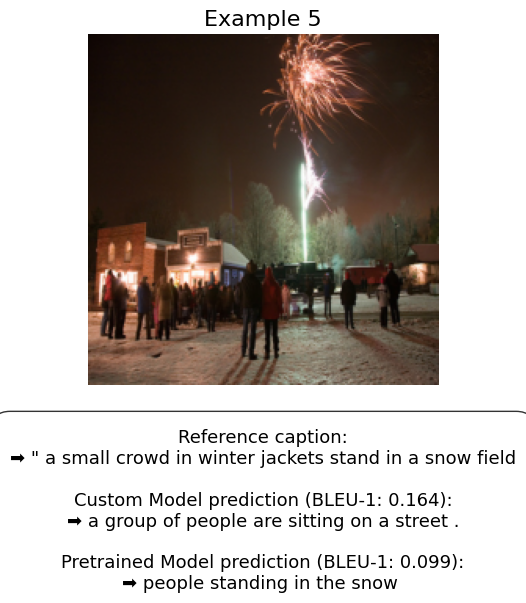

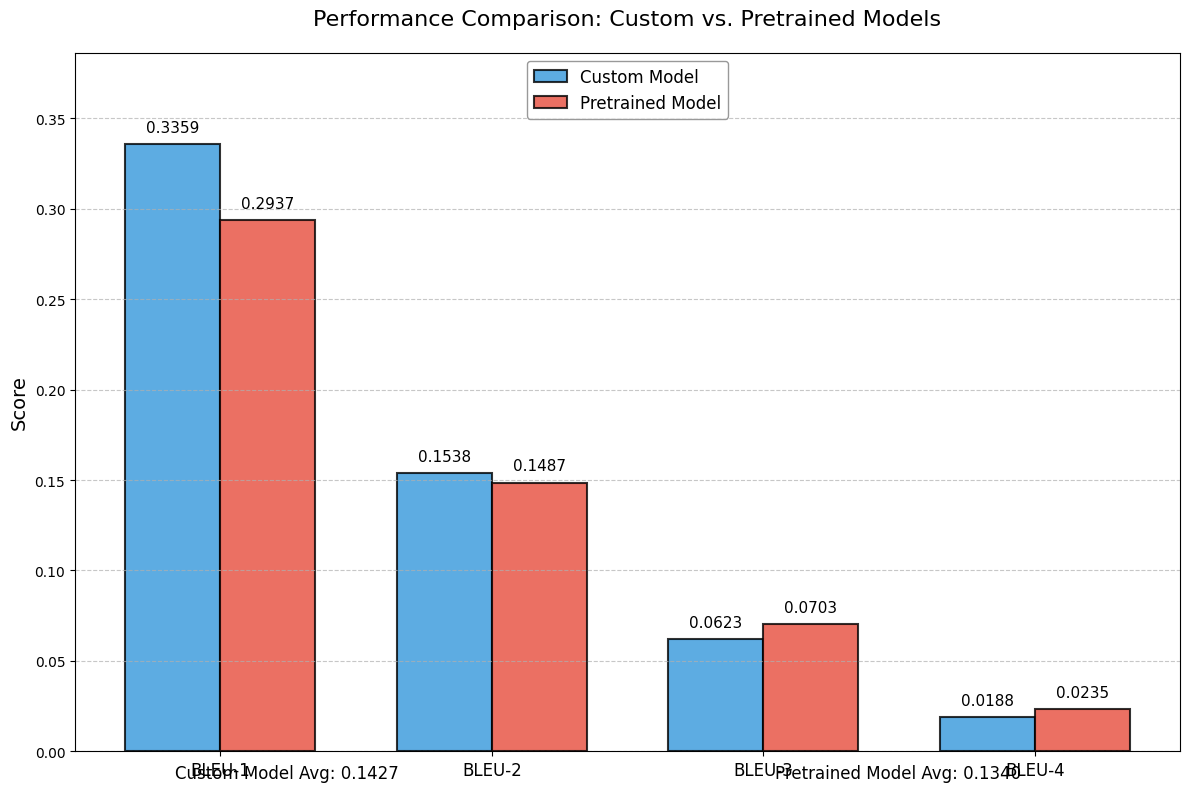

In [35]:
# Load and evaluate pretrained model
pretrained_model, image_processor, tokenizer, gen_kwargs = load_pretrained_model()
pretrained_examples, pretrained_metrics = evaluate_pretrained_model(
    pretrained_model, image_processor, tokenizer, gen_kwargs, test_loader, num_samples=10
)
# Compare models
custom_examples_list = custom_examples[0] if isinstance(custom_examples, tuple) else custom_examples
pretrained_examples_list = pretrained_examples[0] if isinstance(pretrained_examples, tuple) else pretrained_examples

# Pass the correct metrics tuples separately  
compare_models((custom_examples_list, custom_metrics), (pretrained_examples_list, pretrained_metrics), num_samples=5)

## **interactive ui for testing the models**

In [ ]:
import ipywidgets as widgets
from IPython.display import display, HTML
import io
from PIL import Image
import numpy as np
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas
import base64
import random  # Added for better example selection
import pandas as pd

# Define image transformation for the models
def get_transform():
    return transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

# Fixed function to convert uploaded image to tensor
def process_uploaded_image(content):
    """Process uploaded image content to tensor"""
    try:
        # Debug info
        print(f"Content type: {type(content)}")
        
        # Handle different input formats
        if isinstance(content, tuple):
            # For tuple containing a Bunch object (like in the error case)
            if len(content) == 1 and hasattr(content[0], 'content'):
                content = content[0].content
                print(f"Extracted content from Bunch object: {type(content)}")
            elif len(content) >= 2:
                content = content[1]
                print(f"Extracted content from tuple: {type(content)}")
            else:
                raise ValueError(f"Tuple doesn't have expected format: {content}")
        elif isinstance(content, dict) and 'content' in content:
            content = content['content']
        elif hasattr(content, 'content'):
            content = content.content
        
        # Convert memoryview to bytes if needed
        if isinstance(content, memoryview):
            content = content.tobytes()
        
        # Final check to ensure we have bytes
        if not isinstance(content, bytes):
            raise TypeError(f"Could not extract bytes content from {type(content)}")
            
        # Open the image
        image = Image.open(io.BytesIO(content)).convert('RGB')
        transform = get_transform()
        image_tensor = transform(image)
        return image, image_tensor
        
    except Exception as e:
        print(f"Error in process_uploaded_image: {str(e)}")
        print(f"Content type: {type(content)}")
        if isinstance(content, tuple):
            print(f"Tuple length: {len(content)}")
            print(f"Tuple elements types: {[type(x) for x in content]}")
        raise

# Button click handler with fixed implementation
def on_button_click(b):
    with output_area:
        output_area.clear_output()
        
        if not file_upload.value:
            print("Please upload an image first.")
            return
        
        try:
            # Debug information
            print(f"File upload value type: {type(file_upload.value)}")
            
            # Extract content based on the structure
            content = file_upload.value
            
            # Process the image
            print("Processing image...")
            image, image_tensor = process_uploaded_image(content)
            
            # Get captions from both models
            print("Generating captions with custom model...")
            custom_caption, alphas = generate_custom_caption(image_tensor)
            
            print("Generating captions with pretrained model...")
            pretrained_caption = generate_pretrained_caption(image)
            
            # Display results
            width, height = image.size
            aspect_ratio = height/width
            img_width = 500
            img_height = int(img_width * aspect_ratio)
            
            # Convert PIL image to base64 for display
            buffered = io.BytesIO()
            image.save(buffered, format="PNG")
            img_str = base64.b64encode(buffered.getvalue()).decode()
            
            # Display original image
            display(HTML(f"""
            <div style="text-align: center;">
                <img src="data:image/png;base64,{img_str}" width="{img_width}" height="{img_height}" />
                <h3>Generated Captions</h3>
            </div>
            """))
            
            # Display captions
            display(HTML(f"""
            <div class="caption-box custom-caption">
                <div class="model-title">Custom Model:</div>
                {custom_caption}
            </div>
            <div class="caption-box pretrained-caption">
                <div class="model-title">Pretrained Model:</div>
                {pretrained_caption}
            </div>
            """))
            
            # Display attention visualization
            print("\nAttention Visualization (Custom Model):")
            caption_words = custom_caption.split()
            display(HTML(get_attention_plot(image_tensor, caption_words, alphas)))
            
        except Exception as e:
            print(f"Error processing image: {str(e)}")
            import traceback
            traceback.print_exc()

# Function to generate caption using custom model
def generate_custom_caption(image_tensor):
    image_tensor = image_tensor.to(device)
    with torch.no_grad():
        predicted_caption, alphas = model.caption_image(image_tensor, vocab)
    return " ".join(predicted_caption), alphas

# Function to generate caption using pretrained model
def generate_pretrained_caption(image):
    pixel_values = image_processor(image, return_tensors="pt").pixel_values.to(device)
    with torch.no_grad():
        output_ids = pretrained_model.generate(pixel_values, **gen_kwargs)
    caption = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    return caption

# Function to plot attention on the image
def get_attention_plot(image_tensor, caption, alphas):
    fig = Figure(figsize=(12, 8))
    canvas = FigureCanvas(fig)
    
    # Only show up to 9 attention maps
    words_to_show = min(9, len(caption))
    
    # Calculate grid size
    if words_to_show <= 3:
        rows, cols = 1, words_to_show + 1
    else:
        rows = (words_to_show + 1) // 4 + 1
        cols = min(4, words_to_show + 1)
    
    # Convert tensor image to numpy for display
    img = image_tensor.permute(1, 2, 0).cpu().detach().numpy()
    img = (img * np.array([0.229, 0.224, 0.225])) + np.array([0.485, 0.456, 0.406])
    img = img.clip(0, 1)
    
    # Add original image
    ax = fig.add_subplot(rows, cols, 1)
    ax.imshow(img)
    ax.set_title('Original Image', fontsize=12)
    ax.axis('off')
    
    # Add attention maps
    for i in range(min(words_to_show, len(caption))):
        ax = fig.add_subplot(rows, cols, i + 2)
        ax.imshow(img)
        
        # Get attention map
        alpha = alphas[i].cpu().detach()
        attention_size = int(np.sqrt(alpha.numel()))
        att_map = alpha.reshape(attention_size, attention_size).numpy()
        
        # Overlay attention
        ax.imshow(att_map, alpha=0.7, cmap='hot')
        ax.set_title(caption[i], fontsize=12)
        ax.axis('off')
    
    fig.tight_layout()
    
    # Convert plot to image
    buf = io.BytesIO()
    fig.savefig(buf, format='png')
    buf.seek(0)
    img_str = base64.b64encode(buf.read()).decode('utf-8')
    
    return f'<img src="data:image/png;base64,{img_str}" />'

# Debug function for file upload values
def debug_file_upload(change):
    """Debug helper to inspect file upload widget values"""
    if change.name == 'value' and change.new:
        print(f"New upload value type: {type(change.new)}")
        if isinstance(change.new, dict):
            print(f"Dictionary keys: {list(change.new.keys())}")
            for k in change.new:
                print(f"  Key '{k}' has type: {type(change.new[k])}")
                # Print structure of first item
                break
        elif isinstance(change.new, tuple):
            print(f"Tuple of length {len(change.new)}")
            for i, item in enumerate(change.new):
                print(f"  Item {i} has type: {type(item)}")
                if hasattr(item, "__dict__"):
                    print(f"  Attributes: {dir(item)[:10]}...")

# Main UI function
def create_captioning_ui():
    style = """
    <style>
        .widget-label { font-size: 1.2em; font-weight: bold; }
        .output_subarea { max-width: 100%; }
        .caption-box { 
            padding: 10px; 
            border-radius: 5px; 
            margin: 10px 0; 
            font-size: 1.1em;
        }
        .custom-caption { background-color: #e3f2fd; border: 1px solid #2196F3; }
        .pretrained-caption { background-color: #f1f8e9; border: 1px solid #8bc34a; }
        .model-title { font-weight: bold; margin-bottom: 5px; }
        .metrics { font-size: 0.9em; color: #666; }
        .main-title { font-size: 1.5em; font-weight: bold; margin-bottom: 20px; }
    </style>
    """
    
    # Create widgets
    header = widgets.HTML(value=f"{style}<div class='main-title'>Image Captioning Model Comparison</div>")
    file_upload = widgets.FileUpload(description='Upload Image', accept='image/*', multiple=False)
    generate_button = widgets.Button(description='Generate Captions', disabled=True, 
                                   button_style='primary', icon='image')
    output_area = widgets.Output()
    
    # Enable button when file is uploaded
    def on_upload_change(change):
        generate_button.disabled = len(file_upload.value) == 0
    file_upload.observe(on_upload_change, names='value')
    
    # Button click handler with fixed implementation
    def on_button_click(b):
        with output_area:
            output_area.clear_output()
            
            if not file_upload.value:
                print("Please upload an image first.")
                return
            
            try:
                # Debug information
                print(f"File upload value type: {type(file_upload.value)}")
                
                # Extract content based on the structure
                content = file_upload.value
                
                # Process the image
                print("Processing image...")
                image, image_tensor = process_uploaded_image(content)
                
                # Get captions from both models
                print("Generating captions with custom model...")
                custom_caption, alphas = generate_custom_caption(image_tensor)
                
                print("Generating captions with pretrained model...")
                pretrained_caption = generate_pretrained_caption(image)
                
                # Display results
                width, height = image.size
                aspect_ratio = height/width
                img_width = 500
                img_height = int(img_width * aspect_ratio)
                
                # Convert PIL image to base64 for display
                buffered = io.BytesIO()
                image.save(buffered, format="PNG")
                img_str = base64.b64encode(buffered.getvalue()).decode()
                
                # Display original image
                display(HTML(f"""
                <div style="text-align: center;">
                    <img src="data:image/png;base64,{img_str}" width="{img_width}" height="{img_height}" />
                    <h3>Generated Captions</h3>
                </div>
                """))
                
                # Display captions
                display(HTML(f"""
                <div class="caption-box custom-caption">
                    <div class="model-title">Custom Model:</div>
                    {custom_caption}
                </div>
                <div class="caption-box pretrained-caption">
                    <div class="model-title">Pretrained Model:</div>
                    {pretrained_caption}
                </div>
                """))
                
                # Display attention visualization
                print("\nAttention Visualization (Custom Model):")
                caption_words = custom_caption.split()
                display(HTML(get_attention_plot(image_tensor, caption_words, alphas)))
                
            except Exception as e:
                print(f"Error processing image: {str(e)}")
                import traceback
                traceback.print_exc()
    
    # Connect button click to handler
    generate_button.on_click(on_button_click)
    
    # Lathet the widgets
    ui = widgets.VBox([header, 
                      widgets.HBox([file_upload, generate_button]), 
                      output_area])
    
    display(ui)

# For comparison/evaluation function, add random sampling to avoid showing the same image
def compare_models(custom_data, pretrained_data, num_samples=5):
    """
    Compare custom and pretrained models with better visualization and random sampling
    """
    # Unpack the data correctly
    custom_examples, custom_metrics = custom_data
    pretrained_examples, pretrained_metrics = pretrained_data
    
    # Create a list of indices to display, ensuring they're unique
    if isinstance(custom_examples, list):
        total_examples = min(len(custom_examples), len(pretrained_examples))
        if total_examples < num_samples:
            num_samples = total_examples
            print(f"Only {num_samples} examples available.")
            
        # Use random sampling without replacement
        indices = random.sample(range(total_examples), num_samples)
    else:
        # If not a list, just use sequential indices
        indices = range(min(num_samples, 1))
    
    print(f"Displaying {num_samples} random examples with indices: {indices}")
    
    # First display side-by-side image comparisons
    for i, idx in enumerate(indices):
        # Setup the figure
        plt.figure(figsize=(15, 6))
        
        # Get the image
        image = custom_examples[idx]['image'] if isinstance(custom_examples, list) else custom_examples['image']
        img = image.permute(1, 2, 0).cpu().detach().numpy()
        img = (img * np.array([0.229, 0.224, 0.225])) + np.array([0.485, 0.456, 0.406])
        img = img.clip(0, 1)
        
        # Display the image
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Example {i+1} (Index: {idx})", fontsize=16)
        
        # Get the corresponding custom and pretrained examples
        custom_ex = custom_examples[idx] if isinstance(custom_examples, list) else custom_examples
        pretrained_ex = pretrained_examples[idx] if isinstance(pretrained_examples, list) else pretrained_examples
        
        # Create a formatted text block for captions
        text_block = (
            f"Reference caption:\n"
            f"➡️ {custom_ex['reference']}\n\n"
            f"Custom Model prediction (BLEU-1: {custom_ex['bleu1']:.3f}):\n"
            f"➡️ {custom_ex['prediction']}\n\n"
            f"Pretrained Model prediction (BLEU-1: {pretrained_ex['bleu1']:.3f}):\n"
            f"➡️ {pretrained_ex['prediction']}"
        )
        
        # Add the text block beneath the image
        plt.figtext(0.5, 0.01, text_block, ha='center', fontsize=13, 
                   bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=1'))
        
        plt.tight_layout()
        plt.subplots_adjust(bottom=0.35)  # Make room for text
        plt.show()
    
    # Now show the metrics comparison chart
    metrics = ['BLEU-1', 'BLEU-2', 'BLEU-3', 'BLEU-4']
    
    # Create a more attractive bar chart
    plt.figure(figsize=(12, 8))
    
    # Set bar positions
    x = np.arange(len(metrics))
    width = 0.35
    
    # Create bars with a more attractive style
    custom_bars = plt.bar(x - width/2, custom_metrics, width, label='Custom Model', 
                         color='#3498db', alpha=0.8, edgecolor='black', linewidth=1.5)
    pretrained_bars = plt.bar(x + width/2, pretrained_metrics, width, label='Pretrained Model', 
                             color='#e74c3c', alpha=0.8, edgecolor='black', linewidth=1.5)
    
    # Add value labels on bars
    for bars in [custom_bars, pretrained_bars]:
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                    f'{height:.4f}', ha='center', va='bottom', fontsize=11)
    
    # Customize chart
    plt.ylabel('Score', fontsize=14)
    plt.title('Performance Comparison: Custom vs. Pretrained Models', fontsize=16, pad=20)
    plt.xticks(x, metrics, fontsize=12)
    plt.yticks(fontsize=10)
    plt.ylim(0, max(max(custom_metrics), max(pretrained_metrics)) * 1.15)  # Add some headroom
    
    # Add a grid for better readability
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Add legend with better positioning
    plt.legend(loc='upper center', fontsize=12, frameon=True, facecolor='white', edgecolor='gray')
    
    plt.tight_layout()
    plt.show()

# Call the function to create and display the UI
create_captioning_ui()